# Long-Run Fixed-Nu CCD vs RCD Proxy Comparison

This notebook tests a focused question in the LVG smoothing project:

> If we keep the original LVG knot locations fixed, which sigma-only coordinate descent method most reliably reduces the raw jump objective `J` while preserving bid-ask feasibility?

The comparison is intentionally controlled. Every method starts from the same calibrated LVG theta for each option chain, keeps the same nus fixed, keeps the same bid-ask constraints, and runs for the same iteration count. The only things being changed are:

1. the coordinate update order: deterministic cyclic coordinate descent (CCD) versus random coordinate descent (RCD), and
2. the proxy objective used to guide sigma updates: adjacent-sigma smoothing versus adjacent inverse-variance smoothing.

The final metric is always the raw LVG jump objective `J`, not the proxy objective. This matters because the proxy is only a computational guide; the research question is whether the resulting LVG curve is smoother in the raw second-derivative jump sense.


## Step 0: configuration

This run removes adaptive nu insertion from the main experiment. The purpose is to isolate the fixed-nu sigma optimizer. For each option chain, the notebook tests four methods:

| Method name | Update order | Proxy objective |
|---|---:|---:|
| `CCD_regular` | deterministic cyclic order | adjacent sigma differences |
| `RCD_regular` | random coordinate order | adjacent sigma differences |
| `CCD_inverse_variance` | deterministic cyclic order | adjacent inverse-variance differences |
| `RCD_inverse_variance` | random coordinate order | adjacent inverse-variance differences |

Here `cyclic` means ordinary CCD: cycle through sigma coordinates in a fixed deterministic order. Here `random` means RCD: draw a random coordinate order using a fixed random seed so the experiment is reproducible.

The long run uses 100 SPX option chains, 20,000 coordinate updates per method, and records convergence every 500 iterations. Existing CSV results are reused when `FORCE_RERUN = False`, so the notebook can resume instead of repeating completed chains.


In [47]:
import os
import time
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/lvg_matplotlib_cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

DATA_FILE = "SPX_opt_2011_2012.csv"
QUOTE_DATE = None
MIN_STRIKES = 20

# 100-chain fixed-nu comparison across the full SPX file.
RUN_MODE = "fixed_nu_100_chain_test"

RUN_CONFIGS = {
    "quick_fixed_nu_proxy_test": {
        "MAX_CHAINS": 8,
        "PROXY_KINDS": ["regular", "inverse_variance"],
        "UPDATE_ORDERS": ["cyclic", "random"],
        "CCD_ITERATIONS": 3000,
        "RECORD_EVERY": 250,
        "FORCE_RERUN": True,
    },
    "fixed_nu_100_chain_test": {
        "MAX_CHAINS": 100,
        "PROXY_KINDS": ["regular", "inverse_variance"],
        "UPDATE_ORDERS": ["cyclic", "random"],
        "CCD_ITERATIONS": 20000,
        "RECORD_EVERY": 500,
        "FORCE_RERUN": False,
    },
}

if RUN_MODE not in RUN_CONFIGS:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

for key, value in RUN_CONFIGS[RUN_MODE].items():
    globals()[key] = value

ORDER_LABELS = {
    "cyclic": "CCD",
    "random": "RCD",
}

print(f"RUN_MODE = {RUN_MODE}")
print(f"chains = {MAX_CHAINS}")
print(f"proxy kinds = {PROXY_KINDS}")
print(f"update orders = {UPDATE_ORDERS}")
print(f"CCD/RCD iterations = {CCD_ITERATIONS}")
print(f"record every = {RECORD_EVERY}")
print(f"force rerun = {FORCE_RERUN}")
print(f"method settings per chain = {len(PROXY_KINDS) * len(UPDATE_ORDERS)}")

CCD_STEP_TRIALS = 6
RANDOM_SEED = 123

OUTPUT_DIR = Path("outputs/fixed_nu_proxy_100_chain")
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

EPS = 1e-10
SIGMA_FLOOR = 1e-8


RUN_MODE = fixed_nu_100_chain_test
chains = 100
proxy kinds = ['regular', 'inverse_variance']
update orders = ['cyclic', 'random']
CCD/RCD iterations = 20000
record every = 500
force rerun = False
method settings per chain = 4


## Step 1: SPX quote processing

The raw SPX file contains option quotes by quote date, expiration, strike, option type, bid, and ask. For each quote date and expiration, the code first estimates the discount factor `D` and forward `F` from put-call parity:

$$
C(K)-P(K)=D(F-K)=DF-DK.
$$

This is a linear relation in strike. The intercept estimates `DF`; the slope estimates `-D`; therefore the forward is `F=(DF)/D`.

The LVG homework/lecture formulas use adjusted strikes and adjusted call prices. The conversion is

$$
\hat K = K\frac{S_0}{F}, \qquad \hat C = \frac{S_0}{DF}C.
$$

The notebook also tightens adjusted bid-ask bounds using both calls and puts. This is useful because put-call parity can imply a stricter bound than the raw call quote alone. After this step, each chain is represented internally as

```text
K, bid, ask, S0, D, F, T
```

where `K`, `bid`, and `ask` are already in the adjusted LVG convention.


In [48]:
def find_data_file(file_name):
    candidates = [
        Path(file_name),
        Path("partner_lvg_private") / file_name,
        Path.cwd() / file_name,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {file_name}")


def parse_yyyymmdd(value):
    return pd.to_datetime(str(int(value)), format="%Y%m%d")


def implied_D_F(chain):
    calls = chain[chain.cp_flag == "C"].groupby("K").agg(
        cb=("best_bid", "first"), ca=("best_offer", "first")
    )
    puts = chain[chain.cp_flag == "P"].groupby("K").agg(
        pb=("best_bid", "first"), pa=("best_offer", "first")
    )
    merged = calls.join(puts, how="outer").reset_index()
    liquid = merged[(merged.cb > 0) & (merged.pb > 0) & (merged.ca > 0) & (merged.pa > 0)]
    if len(liquid) < 3:
        return None

    K = liquid.K.to_numpy(dtype=float)
    lower = (liquid.cb - liquid.pa).to_numpy(dtype=float)
    upper = (liquid.ca - liquid.pb).to_numpy(dtype=float)

    rows = []
    rhs = []
    for k, lo, hi in zip(K, lower, upper):
        # y = A - D*K. We solve for [A, D, t] with max slack t.
        rows.append([-1.0, k, 1.0])
        rhs.append(-lo)
        rows.append([1.0, -k, 1.0])
        rhs.append(hi)

    result = linprog(
        [0.0, 0.0, -1.0],
        A_ub=np.asarray(rows),
        b_ub=np.asarray(rhs),
        bounds=[(None, None), (None, None), (0, None)],
        method="highs",
    )
    if not result.success:
        call_mid = 0.5 * (liquid.cb + liquid.ca)
        put_mid = 0.5 * (liquid.pb + liquid.pa)
        slope, intercept = np.polyfit(K, (call_mid - put_mid).to_numpy(dtype=float), 1)
        D = -float(slope)
        F = float(intercept / D) if D > 0 else np.nan
        t = np.nan
    else:
        A, D, t = result.x
        F = float(A / D) if D > 0 else np.nan
        D = float(D)

    if not (0 < D < 1.2 and F > 0):
        return None
    return D, F, merged, float(t)


def estimate_spot_from_date(raw, quote_date):
    one_day = raw[raw["date"] == quote_date].copy()
    values = []
    for exdate, chain in one_day.groupby("exdate"):
        result = implied_D_F(chain)
        if result is None:
            continue
        D, F, merged, slack = result
        T = np.busday_count(
            np.datetime64(parse_yyyymmdd(quote_date).date()),
            np.datetime64(parse_yyyymmdd(exdate).date()),
        ) / 252.0
        if T > 0:
            values.append((T, D * F))
    if not values:
        raise ValueError(f"Could not infer S0 for date {quote_date}")
    Ts = np.array([v[0] for v in values], dtype=float)
    DFs = np.array([v[1] for v in values], dtype=float)
    if len(values) >= 2:
        slope, intercept = np.polyfit(Ts, np.log(DFs), 1)
        return float(np.exp(intercept))
    return float(DFs[0])


def chain_maturity_years(quote_date, exdate):
    return np.busday_count(
        np.datetime64(parse_yyyymmdd(quote_date).date()),
        np.datetime64(parse_yyyymmdd(exdate).date()),
    ) / 252.0


def maturity_bucket(T):
    if T <= 0.08:
        return "short"
    if T <= 0.25:
        return "medium"
    if T <= 0.75:
        return "long"
    return "very_long"


def eligible_chains(raw, min_strikes=MIN_STRIKES):
    rows = []
    for (date, exdate), chain in raw.groupby(["date", "exdate"]):
        calls = chain[chain.cp_flag == "C"]
        puts = chain[chain.cp_flag == "P"]
        common = np.intersect1d(calls.K.unique(), puts.K.unique())
        if len(common) < min_strikes:
            continue
        T = chain_maturity_years(int(date), int(exdate))
        if T <= 0:
            continue
        rows.append({
            "date": int(date),
            "exdate": int(exdate),
            "T": float(T),
            "maturity_bucket": maturity_bucket(T),
            "common_strikes": int(len(common)),
        })
    return pd.DataFrame(rows)


def select_chains(raw, max_chains=MAX_CHAINS, min_strikes=MIN_STRIKES):
    eligible = eligible_chains(raw, min_strikes=min_strikes)
    if eligible.empty:
        raise ValueError("No eligible chains found")

    eligible = eligible.sort_values(["date", "T", "exdate"]).reset_index(drop=True)
    buckets = ["short", "medium", "long", "very_long"]
    per_bucket = int(np.ceil(max_chains / len(buckets)))
    selected_parts = []

    for bucket in buckets:
        group = eligible[eligible["maturity_bucket"] == bucket].copy()
        if group.empty:
            continue
        # Spread chains across the two-year sample instead of taking adjacent dates.
        take = min(per_bucket, len(group))
        positions = np.linspace(0, len(group) - 1, take).round().astype(int)
        selected_parts.append(group.iloc[positions])

    selected = pd.concat(selected_parts, ignore_index=True).drop_duplicates(["date", "exdate"])

    if len(selected) < max_chains:
        remaining = eligible.merge(selected[["date", "exdate"]], on=["date", "exdate"], how="left", indicator=True)
        remaining = remaining[remaining["_merge"] == "left_only"].drop(columns=["_merge"])
        need = max_chains - len(selected)
        if len(remaining) > 0:
            positions = np.linspace(0, len(remaining) - 1, min(need, len(remaining))).round().astype(int)
            selected = pd.concat([selected, remaining.iloc[positions]], ignore_index=True)

    selected = selected.sort_values(["date", "T", "exdate"]).head(max_chains).reset_index(drop=True)
    return selected


def build_adjusted_chain(raw, quote_date, exdate, min_strikes=MIN_STRIKES):
    raw = raw.copy()
    if "K" not in raw.columns:
        raw["K"] = raw["strike_price"] / 1000.0
    S0 = estimate_spot_from_date(raw, quote_date)
    chain = raw[(raw.date == quote_date) & (raw.exdate == exdate)].copy()
    result = implied_D_F(chain)
    if result is None:
        raise ValueError(f"Could not infer D/F for {quote_date}, {exdate}")
    D, F, merged, parity_slack = result
    T = np.busday_count(
        np.datetime64(parse_yyyymmdd(quote_date).date()),
        np.datetime64(parse_yyyymmdd(exdate).date()),
    ) / 252.0

    mfac = S0 / (D * F)
    Khat = merged.K.to_numpy(dtype=float) * S0 / F

    ca = np.where(pd.notna(merged.ca), merged.ca.to_numpy(dtype=float), F)
    pa = np.where(pd.notna(merged.pa), merged.pa.to_numpy(dtype=float), F)
    cb = np.where(pd.notna(merged.cb), merged.cb.to_numpy(dtype=float), 0.0)
    pb = np.where(pd.notna(merged.pb), merged.pb.to_numpy(dtype=float), 0.0)

    intrinsic = np.maximum(S0 - Khat, 0.0)
    ask = np.minimum(mfac * ca, mfac * pa + (S0 - Khat))
    bid = np.maximum.reduce([mfac * cb, mfac * pb + (S0 - Khat), intrinsic])
    keep = np.isfinite(Khat) & np.isfinite(bid) & np.isfinite(ask) & (ask >= bid)
    Khat, bid, ask = Khat[keep], bid[keep], ask[keep]
    order = np.argsort(Khat)
    Khat, bid, ask = Khat[order], bid[order], ask[order]
    unique = np.concatenate([[True], np.diff(Khat) > 1e-9])
    Khat, bid, ask = Khat[unique], bid[unique], ask[unique]

    if len(Khat) < min_strikes:
        raise ValueError(f"Only {len(Khat)} strikes after cleaning")

    return {
        "date": quote_date,
        "exdate": int(exdate),
        "T": float(T),
        "D": float(D),
        "F": float(F),
        "S0": float(S0),
        "K": Khat,
        "bid": bid,
        "ask": ask,
        "bid_ask": np.column_stack([Khat, bid, ask]),
    }


raw_spx = pd.read_csv(find_data_file(DATA_FILE))
raw_spx["K"] = raw_spx["strike_price"] / 1000.0
chains_to_run = select_chains(raw_spx, MAX_CHAINS, MIN_STRIKES)
print(f"Selected {len(chains_to_run)} chains across {chains_to_run['date'].nunique()} quote dates")
display(chains_to_run.groupby("maturity_bucket").size().rename("chains"))
chains_to_run


Selected 100 chains across 88 quote dates


maturity_bucket
long         25
medium       25
short        25
very_long    25
Name: chains, dtype: int64

,date,exdate,T,maturity_bucket,common_strikes
0,20110103,20110107,0.015873,short,31
1,20110103,20110219,0.138889,medium,156
2,20110103,20110416,0.297619,long,40
3,20110103,20110930,0.769841,very_long,31
4,20110131,20110319,0.138889,medium,160
...,...,...,...,...,...
95,20121213,20121228,0.043651,short,71
96,20121231,20130125,0.075397,short,71
97,20121231,20130328,0.250000,medium,48
98,20121231,20130628,0.511905,long,44


## Step 2: LVG interpolation formulas

The LVG curve is represented through a time-value function

$$
V(K)=C(K)-\max(S_0-K,0).
$$

On each interval between adjacent knots, the LVG construction writes `V(K)` as a linear combination of exponentials. The parameter vector is

$$
\theta = (\nu^{L},\sigma^{L},\nu^{R},\sigma^{R}),
$$

stored in code as

```text
[left nus, left sigmas, right nus, right sigmas]
```

where:

- `nu` values are the interval endpoints/knots in strike space,
- `sigma` values are the piecewise diffusion coefficients attached to the intervals,
- the left wing lies below spot `S0`,
- the right wing lies above spot `S0`.

The functions below reproduce the homework construction. First, an arbitrage-free adjusted call curve is chosen inside the bid-ask region. Then the LVG interpolation recursively constructs the left- and right-wing exponential pieces and the matching constants at spot.


In [49]:

def _analytic_center_newton(M, b, x0, max_iter=100, tol=1e-10):
    x = np.asarray(x0, float).copy()
    n = len(x)
    for _ in range(max_iter):
        slack = b - M @ x
        if np.any(slack <= 0):
            break
        inv = 1.0 / slack
        grad = M.T @ inv
        hess = (M * (inv * inv)[:, None]).T @ M
        hess[np.diag_indices(n)] += 1e-12 * (np.trace(hess) / max(n, 1) + 1.0)
        try:
            step = np.linalg.solve(hess, -grad)
        except np.linalg.LinAlgError:
            step, *_ = np.linalg.lstsq(hess, -grad, rcond=None)
        decrement = float(-grad @ step)
        if decrement <= tol:
            break
        Mstep = M @ step
        positive = Mstep > 0
        max_step = np.min(slack[positive] / Mstep[positive]) if np.any(positive) else 1.0
        alpha = min(1.0, 0.99 * max_step)
        f0 = -np.sum(np.log(slack))
        while alpha > 1e-14:
            new_slack = b - M @ (x + alpha * step)
            if np.all(new_slack > 0) and -np.sum(np.log(new_slack)) <= f0 - 1e-4 * alpha * decrement:
                break
            alpha *= 0.5
        x = x + alpha * step
        if alpha <= 1e-14:
            break
    return x


def analytic_center_call_prices(K, bid, ask, S0):
    K = np.asarray(K, dtype=float)
    bid = np.asarray(bid, dtype=float)
    ask = np.asarray(ask, dtype=float)
    n = len(K)
    L = 0.0
    Kbar = max(2000.0, float(K[-1]) + 100.0)

    lower = np.maximum.reduce([np.zeros(n), S0 - K, bid])
    upper = np.minimum(np.full(n, S0), ask)

    rows = []
    rhs = []

    # Monotonicity: C_{i+1} - C_i <= 0.
    for i in range(n - 1):
        row = np.zeros(n)
        row[i] = -1.0
        row[i + 1] = 1.0
        rows.append(row)
        rhs.append(0.0)

    # Convexity on nonuniform strike grid.
    for i in range(1, n - 1):
        row = np.zeros(n)
        h_prev = K[i] - K[i - 1]
        h_next = K[i + 1] - K[i]
        row[i - 1] = -1.0 / h_prev
        row[i] = 1.0 / h_prev + 1.0 / h_next
        row[i + 1] = -1.0 / h_next
        rows.append(row)
        rhs.append(0.0)

    # Boundary-style rows matching the homework construction.
    row = np.zeros(n)
    row[0] = -1.0
    rows.append(row)
    rhs.append(K[0] - L - S0)

    row = np.zeros(n)
    row[-1] = -1.0
    rows.append(row)
    rhs.append(0.0)

    row = np.zeros(n)
    row[0] = 1.0 / (K[0] - L) + 1.0 / (K[1] - K[0])
    row[1] = -1.0 / (K[1] - K[0])
    rows.append(row)
    rhs.append(S0 / (K[0] - L))

    row = np.zeros(n)
    row[-2] = -1.0 / (K[-1] - K[-2])
    row[-1] = 1.0 / (Kbar - K[-1]) + 1.0 / (K[-1] - K[-2])
    rows.append(row)
    rhs.append(0.0)

    M = np.vstack([np.asarray(rows), np.eye(n), -np.eye(n)])
    b = np.concatenate([np.asarray(rhs), upper, -lower])

    # Chebyshev center LP for strictly feasible starting point.
    row_norms = np.linalg.norm(M, axis=1)
    A_lp = np.hstack([M, row_norms[:, None]])
    c = np.zeros(n + 1)
    c[-1] = -1.0
    res = linprog(c, A_ub=A_lp, b_ub=b, bounds=[(None, None)] * n + [(0, None)], method="highs")

    if res.success and res.x[-1] > 1e-10:
        x0 = res.x[:n]
        return _analytic_center_newton(M, b, x0)

    # Fallback: clipped midpoint if strict interior is unavailable.
    return np.clip(0.5 * (bid + ask), lower, upper)


def load_theta(S, K, C_h, C_l):
    K = np.asarray(K, dtype=float)
    C_h = np.asarray(C_h, dtype=float)
    C_l = np.asarray(C_l, dtype=float)
    N = len(K)
    L = 0.0
    Kbar = max(2000.0, float(K[-1]) + 100.0)

    # First choose the arbitrage-free adjusted call curve, then interpolate it.
    C = analytic_center_call_prices(K, C_l, C_h, S)
    def Atilde(sigma,A,B,w,K):
        return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)

    def Btilde(sigma,A,B,w,K):
        return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)

    def findSigmaHat(A,B,w,K1,K2,V):
        my_eps = 1.0e-8
        def SigmaHat_obj(sigma):
            return Atilde(sigma,A,B,w,K1) + Btilde(sigma,A,B,w,K1)*(K2-w) - V
        low = my_eps
        high = 1.0
        while (SigmaHat_obj(high) > 0):
            high = 2.0*high
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (SigmaHat_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    def SigmaTilde(sigma,A,B,w,K1,K2,V):
        #sigma_h = findSigmaHat(A,B,w,K1,K2,V)
        my_eps = 1.0e-8
        At = Atilde(sigma,A,B,w,K1)
        Bt = Btilde(sigma,A,B,w,K1)
        def SigmaTilde_obj(sigma_t):
            return 0.5*(At+sigma_t*Bt)*np.exp((K2-w)/sigma_t) + 0.5*(At-sigma_t*Bt)*np.exp(-(K2-w)/sigma_t) - V
        low = my_eps
        high = 1
        while (SigmaTilde_obj(high) > 0):
            high = 2.0*high
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (SigmaTilde_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    def FindSigma(A,B,w,K1,K2,V,B1,sigma_h):
        #sigma_h = findSigmaHat(A,B,w,K1,K2,V)
        my_eps = 1.0e-8
        def FindSigma_obj(sigma):
            sigma_t = SigmaTilde(sigma,A,B,w,K1,K2,V)
            At = Atilde(sigma,A,B,w,K1)
            Bt = Btilde(sigma,A,B,w,K1)
            return B1 - (0.5/sigma_t)*(At + sigma_t*Bt)*np.exp((K2-w)/sigma_t) + (0.5/sigma_t)*(At - sigma_t*Bt)*np.exp(-(K2-w)/sigma_t)
        low = sigma_h
        high = sigma_h+1
        while (FindSigma_obj(high) > 0):
            high = 2.0*high
        #print(high)
        while (high - low > my_eps):
            mid = 0.5 * (low + high)
            if mid == low or mid == high: return mid
            if (FindSigma_obj(mid) >= 0):
                low = mid
            else:
                high = mid
        return 0.5 * (low + high)

    i0 = 0
    for i in range(N-1):
        if (K[i]<S) & (S<K[i+1]):
            i0 = i
    
    Lt1 = C[i0] + (S-K[i0])*(C[i0]-C[i0-1])/(K[i0]-K[i0-1])
    Lt2 = C[i0+1] + (S-K[i0+1])*(C[i0+2]-C[i0+1])/(K[i0+2]-K[i0+1])
    Lt = max([Lt1,Lt2])
    
    Ut = C[i0]*(K[i0+1]-S)/(K[i0+1]-K[i0]) + C[i0+1]*(S-K[i0])/(K[i0+1]-K[i0])
    
    delta = 0.5
    Vtemp = delta*Lt + (1-delta)*Ut
    
    K1 = [0]
    V1 = [0]
    for i in range(N):
        if (K[i]<S):
            K1.append(K[i])
            V1.append(C[i]-S+K[i])
    
    K2 = [0]
    V2 = [0]
    for i in range(N):
        if (K[N-1-i]>S):
            K2.append(Kbar - K[N-1-i])
            V2.append(C[N-1-i])
    
    K1.append(S)
    K2.append(Kbar-S)
    V1.append(Vtemp)
    V2.append(Vtemp)

    def Interpolate(K,V):
        N = len(K)
        nu = []
        kappa = []
        omega = []
        sigmas = []
        A = V[0]
        delta = 0.5
        #B = delta*(V[1]-V[0])/(K[1]-K[0]) + (1-delta)*V[0]/K[0]
        B = delta*(V[1]-V[0])/(K[1]-K[0])
        for i in range(N-2):
            #print(i)
            K1t = K[i]
            K2t = K[i+1]
            V1t = V[i]
            V2t = V[i+1]
            B1 = delta*(V[i+2]-V2t)/(K[i+2]-K2t) + (1.0-delta)*(V2t-V1t)/(K2t-K1t)
            w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
            sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
            #print(sigma_h)
            sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
            #print(sigma)
            sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
            At = Atilde(sigma,A,B,w,K1t)
            Bt = Btilde(sigma,A,B,w,K1t)
            nu.append(K1t)
            nu.append(w)
            omega.append(1.0/sigma)
            omega.append(1.0/sigma_t)
            kappa.append([0.5*(A+sigma*B),0.5*(A-sigma*B)])
            kappa.append([0.5*(At+sigma_t*Bt),0.5*(At-sigma_t*Bt)])
            sigmas.append(sigma);
            sigmas.append(sigma_t);
            A = V2t
            #B = (0.5/sigma_t)*(At+sigma_t*Bt)*np.exp((K2-w)/sigma_t) - (0.5/sigma_t)*(At-sigma_t*Bt)*np.exp(-(K2-w)/sigma_t)
            B=B1
        return nu, sigmas, B
        
    nu1, sigmas1, B1_last = Interpolate(K1,V1)
    nu2, sigmas2, B2_last = Interpolate(K2,V2)

    delta1 = 0.5
    rho = delta1 + delta1*(V2[-2]-V2[-1])/(K2[-1]-K2[-2]) + (1.0-delta1)*(V1[-1]-V1[-2])/(K1[-1]-K1[-2])

    K1t = K1[-2]
    K2t = K1[-1]
    V1t = V1[-2]
    V2t = V1[-1]
    A = V1t
    B = B1_last
    B1 = rho
    w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
    sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
    sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
    sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
    At = Atilde(sigma,A,B,w,K1t)
    Bt = Btilde(sigma,A,B,w,K1t)
    
    nu1.append(K1t)
    nu1.append(w)
    sigmas1.append(sigma)
    sigmas1.append(sigma_t)

    K1t = K2[-2]
    K2t = K2[-1]
    V1t = V2[-2]
    V2t = V2[-1]
    A = V1t
    B = B2_last
    B1 = 1 - rho
    w = (V2t + B*K1t - A - B1*K2t)/(B-B1)
    sigma_h = findSigmaHat(A,B,w,K1t,K2t,V2t)
    sigma = FindSigma(A,B,w,K1t,K2t,V2t,B1,sigma_h)
    sigma_t = SigmaTilde(sigma,A,B,w,K1t,K2t,V2t)
    At = Atilde(sigma,A,B,w,K1t)
    Bt = Btilde(sigma,A,B,w,K1t)
    
    nu2.append(K1t)
    nu2.append(w)
    sigmas2.append(sigma)
    sigmas2.append(sigma_t)

    initial_sigs1 = np.array(sigmas1)
    initial_sigs2 = np.array(sigmas2[::-1])
    initial_nus1 = np.array(nu1)
    initial_nus2 = Kbar - np.array(nu2[::-1])

    return initial_nus1, initial_sigs1, initial_nus2, initial_sigs2


## Step 3: LVG pricing, derivatives, and raw J

Given theta, the notebook can evaluate the LVG time-value curve `V(K)`, the call curve `C(K)`, the second derivative `C''(K)`, and the normalized quantity `C''(K)/V(K)`.

The raw smoothness objective is built from jumps in `C''` at the interior LVG knots. At a knot `nu_j`, there is a second derivative from the interval on the left and another from the interval on the right. The jump is

$$
\Delta C''(\nu_j)=C''_+(\nu_j)-C''_-(\nu_j).
$$

The raw objective is the sum of squared jumps:

$$
J(\theta)=\sum_j \left(\Delta C''(\nu_j)\right)^2.
$$

This is the objective we ultimately care about. It is not exactly the same as any simple sigma proxy because `C''` also depends on the LVG coefficients, exponential interval shape, knot locations, and level of the time-value curve.


In [50]:
def get_theta_parts(R1, R2, theta):
    left_nu = theta[:R1]
    left_sigma = theta[R1:2 * R1]
    right_nu = theta[2 * R1:2 * R1 + R2]
    right_sigma = theta[2 * R1 + R2:]
    return left_nu, left_sigma, right_nu, right_sigma


def theta_from_parts(left_nu, left_sigma, right_nu, right_sigma):
    return np.concatenate([left_nu, left_sigma, right_nu, right_sigma]).astype(float)


def all_sigmas(R1, R2, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return np.concatenate([left_sigma, right_sigma])


def check_theta_shape(R1, R2, theta):
    return len(theta) == 2 * R1 + 2 * R2


def check_nu_order(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return bool(np.all(np.diff(left_nu) > 0) and np.all(left_nu < S0) and np.all(np.diff(right_nu) > 0) and np.all(right_nu > S0))


def check_positive_sigmas(R1, R2, theta):
    return bool(np.all(all_sigmas(R1, R2, theta) > SIGMA_FLOOR))


def load_c_values(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    nus1_full = np.concatenate([left_nu, [S0]])
    nus2_full = np.concatenate([[S0], right_nu])

    c_v1_unit = []
    dist0 = nus1_full[1] - nus1_full[0]
    c_v1_unit.append((-np.exp(-dist0 / left_sigma[0]), np.exp(dist0 / left_sigma[0])))
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1 / left_sigma[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1_full[j + 2] - nus1_full[j + 1]
        c_v1_unit.append((
            0.5 * (P - left_sigma[j + 1] * S) * np.exp(-dist / left_sigma[j + 1]),
            0.5 * (P + left_sigma[j + 1] * S) * np.exp(dist / left_sigma[j + 1]),
        ))

    c_v2_unit = [None] * R2
    dist_u = nus2_full[-1] - nus2_full[-2]
    c_v2_unit[-1] = (np.exp(dist_u / right_sigma[-1]), -np.exp(-dist_u / right_sigma[-1]))
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1 / right_sigma[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2_full[j] - nus2_full[j - 1]
        c_v2_unit[j - 1] = (
            0.5 * (P - right_sigma[j - 1] * S) * np.exp(dist / right_sigma[j - 1]),
            0.5 * (P + right_sigma[j - 1] * S) * np.exp(-dist / right_sigma[j - 1]),
        )

    v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1]
    Dk_v1 = (1 / left_sigma[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    v2 = c_v2_unit[0][0] + c_v2_unit[0][1]
    Dk_v2 = (1 / right_sigma[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])
    denom = Dk_v1 * v2 - v1 * Dk_v2
    lam1 = v2 / denom
    lam2 = v1 / denom
    return np.array(c_v1_unit) * lam1, np.array(c_v2_unit) * lam2


def V_K(K, R1, R2, S0, theta, c_v1=None, c_v2=None):
    if c_v1 is None or c_v2 is None:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    if K <= S0:
        nus = np.concatenate([left_nu, [S0]])
        idx = np.searchsorted(nus, K, side="left") - 1
        idx = int(np.clip(idx, 0, R1 - 1))
        dist = nus[idx + 1] - K
        return c_v1[idx, 0] * np.exp(dist / left_sigma[idx]) + c_v1[idx, 1] * np.exp(-dist / left_sigma[idx])
    nus = np.concatenate([[S0], right_nu])
    idx = np.searchsorted(nus, K, side="left") - 1
    idx = int(np.clip(idx, 0, R2 - 1))
    dist = K - nus[idx]
    return c_v2[idx, 0] * np.exp(-dist / right_sigma[idx]) + c_v2[idx, 1] * np.exp(dist / right_sigma[idx])


def C_K(K, R1, R2, S0, theta, c_v1=None, c_v2=None):
    value = V_K(K, R1, R2, S0, theta, c_v1, c_v2)
    if K <= S0:
        value += S0 - K
    return value


def C2_K(K, R1, R2, S0, theta, c_v1=None, c_v2=None):
    if c_v1 is None or c_v2 is None:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    if K <= S0:
        nus = np.concatenate([left_nu, [S0]])
        idx = np.searchsorted(nus, K, side="left") - 1
        idx = int(np.clip(idx, 0, R1 - 1))
        dist = nus[idx + 1] - K
        return (c_v1[idx, 0] * np.exp(dist / left_sigma[idx]) + c_v1[idx, 1] * np.exp(-dist / left_sigma[idx])) / (left_sigma[idx] ** 2)
    nus = np.concatenate([[S0], right_nu])
    idx = np.searchsorted(nus, K, side="left") - 1
    idx = int(np.clip(idx, 0, R2 - 1))
    dist = K - nus[idx]
    return (c_v2[idx, 0] * np.exp(-dist / right_sigma[idx]) + c_v2[idx, 1] * np.exp(dist / right_sigma[idx])) / (right_sigma[idx] ** 2)


def C2_over_V(K, R1, R2, S0, theta, c_v1=None, c_v2=None):
    v = V_K(K, R1, R2, S0, theta, c_v1, c_v2)
    if abs(v) < EPS:
        return np.nan
    return C2_K(K, R1, R2, S0, theta, c_v1, c_v2) / v


def model_prices_at_quotes(R1, R2, S0, theta, bid_ask_arr):
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    return np.array([C_K(k, R1, R2, S0, theta, c_v1, c_v2) for k in bid_ask_arr[:, 0]])


def quote_slack_report(R1, R2, S0, theta, bid_ask_arr):
    try:
        prices = model_prices_at_quotes(R1, R2, S0, theta, bid_ask_arr)
    except Exception:
        return {"feasible": False, "min_slack": -np.inf, "min_bid_slack": -np.inf, "min_ask_slack": -np.inf}
    bid_slack = prices - bid_ask_arr[:, 1]
    ask_slack = bid_ask_arr[:, 2] - prices
    return {
        "feasible": bool(np.all(bid_slack >= -1e-7) and np.all(ask_slack >= -1e-7)),
        "min_slack": float(min(np.min(bid_slack), np.min(ask_slack))),
        "min_bid_slack": float(np.min(bid_slack)),
        "min_ask_slack": float(np.min(ask_slack)),
        "num_bid_violations": int(np.sum(bid_slack < -1e-7)),
        "num_ask_violations": int(np.sum(ask_slack < -1e-7)),
    }


def validate_and_check_market(R1, R2, S0, theta, bid_ask_arr):
    if not check_theta_shape(R1, R2, theta):
        return False
    if not check_nu_order(R1, R2, S0, theta):
        return False
    if not check_positive_sigmas(R1, R2, theta):
        return False
    return quote_slack_report(R1, R2, S0, theta, bid_ask_arr)["feasible"]


def jump_contributions_by_knot(R1, R2, S0, theta):
    c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    rows = []
    left_full = np.concatenate([left_nu, [S0]])
    right_full = np.concatenate([[S0], right_nu])

    for j in range(R1 - 1):
        knot = left_full[j + 1]
        left_val = C2_K(knot - 1e-9, R1, R2, S0, theta, c_v1, c_v2)
        right_val = C2_K(knot + 1e-9, R1, R2, S0, theta, c_v1, c_v2)
        jump = right_val - left_val
        rows.append({"knot": knot, "jump": jump, "jump_squared": jump * jump, "wing": "left"})

    for j in range(R2 - 1):
        knot = right_full[j + 1]
        left_val = C2_K(knot - 1e-9, R1, R2, S0, theta, c_v1, c_v2)
        right_val = C2_K(knot + 1e-9, R1, R2, S0, theta, c_v1, c_v2)
        jump = right_val - left_val
        rows.append({"knot": knot, "jump": jump, "jump_squared": jump * jump, "wing": "right"})
    return pd.DataFrame(rows)


def calculate_J(R1, R2, S0, theta, c_v1=None, c_v2=None):
    return float(jump_contributions_by_knot(R1, R2, S0, theta)["jump_squared"].sum())


def J_value(R1, R2, S0, theta):
    return calculate_J(R1, R2, S0, theta)


## Step 4: CCD proxy objectives and update orders

The fixed-nu experiments only change sigmas. The nus remain exactly as they were in the original LVG theta. After each proposed sigma move, the notebook checks bid-ask feasibility and rejects moves that leave the quote region.

The regular proxy is

$$
P_\sigma(\sigma)=\sum_i(\sigma_{i+1}-\sigma_i)^2.
$$

This objective tries to make adjacent diffusion coefficients close to each other. It is simple, stable, and worked well in the one-chain experiments.

The inverse-variance proxy is

$$
P_{\mathrm{inv}}(\sigma)=\sum_i\left(\frac{1}{\sigma_{i+1}^2}-\frac{1}{\sigma_i^2}\right)^2.
$$

This is motivated by the raw jump formula, because second derivatives contain `1/sigma^2` factors. However, it is still only a proxy: raw `J` also depends on the LVG coefficients and the curve level.

For each coordinate update, the code computes the value of the selected sigma that locally minimizes the chosen proxy relative to its neighbors, tries to move toward that value, and accepts only if the proxy decreases and bid-ask feasibility remains true.


In [51]:
def regular_sigma_proxy(sigmas):
    return float(np.sum(np.diff(sigmas) ** 2))


def inverse_variance_proxy(sigmas):
    u = 1.0 / np.maximum(sigmas, SIGMA_FLOOR) ** 2
    return float(np.sum(np.diff(u) ** 2))


def proxy_value(sigmas, proxy_kind):
    if proxy_kind == "regular":
        return regular_sigma_proxy(sigmas)
    if proxy_kind == "inverse_variance":
        return inverse_variance_proxy(sigmas)
    raise ValueError(f"unknown proxy_kind={proxy_kind}")


def coordinate_target(sigmas, index, proxy_kind):
    n = len(sigmas)
    if n == 1:
        return sigmas[index]
    if index == 0:
        return sigmas[1]
    if index == n - 1:
        return sigmas[n - 2]

    left = sigmas[index - 1]
    right = sigmas[index + 1]
    if proxy_kind == "regular":
        return 0.5 * (left + right)

    # Minimize local squared difference in u=1/sigma^2.
    return (np.sqrt(2.0) * left * right) / np.sqrt(left * left + right * right)


def sigma_theta_index(R1, R2, sigma_index):
    if sigma_index < R1:
        return R1 + sigma_index
    return 2 * R1 + R2 + (sigma_index - R1)


def update_order_indices(R1, R2, update_order, rng):
    n = R1 + R2
    if update_order == "cyclic":
        return list(range(n))
    if update_order == "random":
        return list(rng.permutation(n))
    if update_order == "construction":
        left = list(range(R1))
        right = list(range(R1 + R2 - 1, R1 - 1, -1))
        return left + right
    if update_order == "reverse_construction":
        left = list(range(R1 - 1, -1, -1))
        right = list(range(R1, R1 + R2))
        return left + right
    raise ValueError(f"unknown update_order={update_order}")


def coordinate_descent_sigma(
    R1,
    R2,
    S0,
    init_theta,
    bid_ask_arr,
    proxy_kind="regular",
    update_order="cyclic",
    num_iterations=CCD_ITERATIONS,
    random_seed=RANDOM_SEED,
    record_every=None,
):
    theta = init_theta.copy().astype(float)
    rng = np.random.default_rng(random_seed)
    history = []
    accepted = 0

    def record(iteration):
        sigmas = all_sigmas(R1, R2, theta)
        slack = quote_slack_report(R1, R2, S0, theta, bid_ask_arr)
        history.append({
            "iteration": iteration,
            "raw_J": J_value(R1, R2, S0, theta),
            "proxy": proxy_value(sigmas, proxy_kind),
            "min_slack": slack["min_slack"],
            "accepted_moves": accepted,
        })

    if record_every is not None:
        record(0)

    order = update_order_indices(R1, R2, update_order, rng)
    current_proxy = proxy_value(all_sigmas(R1, R2, theta), proxy_kind)

    for iteration in range(1, num_iterations + 1):
        if update_order == "random":
            order = update_order_indices(R1, R2, update_order, rng)
        sigma_index = order[(iteration - 1) % len(order)]
        sigmas = all_sigmas(R1, R2, theta)
        target = coordinate_target(sigmas, sigma_index, proxy_kind)
        direction = target - sigmas[sigma_index]
        if abs(direction) < 1e-14:
            continue

        theta_index = sigma_theta_index(R1, R2, sigma_index)
        improved = False
        step = 1.0
        for _ in range(CCD_STEP_TRIALS):
            candidate = theta.copy()
            candidate[theta_index] += step * direction
            if candidate[theta_index] <= SIGMA_FLOOR:
                step *= 0.5
                continue
            candidate_sigmas = all_sigmas(R1, R2, candidate)
            candidate_proxy = proxy_value(candidate_sigmas, proxy_kind)
            if candidate_proxy < current_proxy and validate_and_check_market(R1, R2, S0, candidate, bid_ask_arr):
                theta = candidate
                current_proxy = candidate_proxy
                accepted += 1
                improved = True
                break
            step *= 0.5

        if record_every is not None and iteration % record_every == 0:
            record(iteration)

    if record_every is not None and (not history or history[-1]["iteration"] != num_iterations):
        record(num_iterations)
    return theta, pd.DataFrame(history), accepted


## Step 5: adaptive nu insertion helpers, kept for later

This notebook's main experiment does **not** add nus or move nus. These helper functions remain here because the next research step is adaptive knot placement.

Conceptually, adding nus increases the number of LVG intervals. This gives the sigma curve more local flexibility, which can reduce raw `J`, but it also increases the parameter dimension. In the present notebook, we deliberately avoid that complication so that the four fixed-nu methods can be compared cleanly.


In [52]:
def insert_one_nu_at_global_sigma_index(R1, R2, S0, theta, sigma_index):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    sigmas = all_sigmas(R1, R2, theta)
    all_nus = np.concatenate([left_nu, [S0], right_nu])

    if sigma_index == R1 - 1:
        # Do not split the interval adjacent to spot across the artificial left/right boundary.
        return None
    if sigma_index < 0 or sigma_index >= len(sigmas) - 1:
        return None

    left_endpoint = all_nus[sigma_index]
    right_endpoint = all_nus[sigma_index + 1]
    if not np.isfinite(left_endpoint + right_endpoint) or right_endpoint <= left_endpoint:
        return None

    new_nu = 0.5 * (left_endpoint + right_endpoint)
    new_sigma = 0.5 * (sigmas[sigma_index] + sigmas[sigma_index + 1])

    if sigma_index < R1:
        new_left_nu = np.insert(left_nu, sigma_index + 1, new_nu)
        new_left_sigma = np.insert(left_sigma, sigma_index + 1, new_sigma)
        return R1 + 1, R2, theta_from_parts(new_left_nu, new_left_sigma, right_nu, right_sigma)

    right_local = sigma_index - R1
    new_right_nu = np.insert(right_nu, right_local + 1, new_nu)
    new_right_sigma = np.insert(right_sigma, right_local + 1, new_sigma)
    return R1, R2 + 1, theta_from_parts(left_nu, left_sigma, new_right_nu, new_right_sigma)


def insertion_priority_indices(R1, R2, S0, theta, mode="raw_J"):
    if mode == "raw_J":
        jumps = jump_contributions_by_knot(R1, R2, S0, theta).sort_values("jump_squared", ascending=False)
        indices = []
        for _, row in jumps.iterrows():
            if row["wing"] == "left":
                left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
                local = int(np.argmin(np.abs(left_nu - row["knot"])))
                indices.append(max(local - 1, 0))
            else:
                left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
                local = int(np.argmin(np.abs(right_nu - row["knot"])))
                indices.append(R1 + max(local - 1, 0))
        return indices

    if mode == "sigma_jump":
        sigmas = all_sigmas(R1, R2, theta)
        diffs = np.abs(np.diff(sigmas))
        return list(np.argsort(diffs)[::-1])

    if mode == "inverse_variance_jump":
        sigmas = all_sigmas(R1, R2, theta)
        u = 1.0 / np.maximum(sigmas, SIGMA_FLOOR) ** 2
        diffs = np.abs(np.diff(u))
        return list(np.argsort(diffs)[::-1])

    raise ValueError(f"unknown insertion mode {mode}")


def adaptive_insert_nus(
    R1,
    R2,
    S0,
    init_theta,
    bid_ask_arr,
    added_budget,
    proxy_kind="regular",
    update_order="cyclic",
    insertion_mode="raw_J",
    screen_iterations=INSERT_SCREEN_CCD_ITERATIONS,
    final_iterations=FINAL_ADAPTIVE_CCD_ITERATIONS,
):
    current_R1 = R1
    current_R2 = R2
    theta = init_theta.copy().astype(float)
    log_rows = []

    if added_budget == 0:
        theta, hist, accepted = coordinate_descent_sigma(
            current_R1, current_R2, S0, theta, bid_ask_arr,
            proxy_kind=proxy_kind, update_order=update_order,
            num_iterations=screen_iterations,
        )
        return current_R1, current_R2, theta, pd.DataFrame(log_rows)

    for addition in range(1, added_budget + 1):
        before_J = J_value(current_R1, current_R2, S0, theta)
        priorities = insertion_priority_indices(current_R1, current_R2, S0, theta, mode=insertion_mode)
        accepted = False

        for sigma_index in priorities:
            proposed = insert_one_nu_at_global_sigma_index(current_R1, current_R2, S0, theta, sigma_index)
            if proposed is None:
                continue
            new_R1, new_R2, candidate = proposed
            if not check_nu_order(new_R1, new_R2, S0, candidate):
                continue
            if not check_positive_sigmas(new_R1, new_R2, candidate):
                continue
            if not validate_and_check_market(new_R1, new_R2, S0, candidate, bid_ask_arr):
                continue

            candidate, _, _ = coordinate_descent_sigma(
                new_R1, new_R2, S0, candidate, bid_ask_arr,
                proxy_kind=proxy_kind, update_order=update_order,
                num_iterations=screen_iterations,
            )
            after_J = J_value(new_R1, new_R2, S0, candidate)
            if validate_and_check_market(new_R1, new_R2, S0, candidate, bid_ask_arr) and after_J < before_J:
                current_R1, current_R2, theta = new_R1, new_R2, candidate
                log_rows.append({
                    "addition": addition,
                    "sigma_index_split": sigma_index,
                    "raw_J_before": before_J,
                    "raw_J_after": after_J,
                    "improvement": before_J - after_J,
                    "R1": current_R1,
                    "R2": current_R2,
                })
                accepted = True
                break

        if not accepted:
            log_rows.append({
                "addition": addition,
                "sigma_index_split": np.nan,
                "raw_J_before": before_J,
                "raw_J_after": before_J,
                "improvement": 0.0,
                "R1": current_R1,
                "R2": current_R2,
            })
            break

    # After the cheap insertion screen, do one longer sigma-only cleanup with the final fixed nus.
    if final_iterations and final_iterations > 0:
        theta, _, _ = coordinate_descent_sigma(
            current_R1, current_R2, S0, theta, bid_ask_arr,
            proxy_kind=proxy_kind, update_order=update_order,
            num_iterations=final_iterations,
        )
    return current_R1, current_R2, theta, pd.DataFrame(log_rows)


## Step 6: fixed-nu experiment runner

For each option chain, this section performs the same sequence:

1. Build the original LVG theta from adjusted bid-ask quotes.
2. Compute the original raw `J`.
3. Run the four fixed-nu sigma-only descent methods.
4. Record raw `J`, proxy values, runtime, accepted moves, feasibility, and quote slack.

The two feasibility quantities to remember are:

- bid slack: `model price - bid`,
- ask slack: `ask - model price`.

A candidate is bid-ask feasible when both are nonnegative up to numerical tolerance. The minimum quote slack tells us how close the final curve is to touching a quote boundary.


In [53]:
def build_initial_theta_for_chain(chain):
    K = chain["K"]
    bid = chain["bid"]
    ask = chain["ask"]
    S0 = chain["S0"]
    left_nu, left_sigma, right_nu, right_sigma = load_theta(S0, K, ask, bid)
    R1 = len(left_sigma)
    R2 = len(right_sigma)
    theta = theta_from_parts(left_nu, left_sigma, right_nu, right_sigma)
    return R1, R2, theta


def result_row(method, chain, R1, R2, theta, baseline_J, runtime=np.nan, extra=None):
    S0 = chain["S0"]
    bid_ask = chain["bid_ask"]
    slack = quote_slack_report(R1, R2, S0, theta, bid_ask)
    raw_J = J_value(R1, R2, S0, theta)
    sigmas = all_sigmas(R1, R2, theta)
    row = {
        "date": chain["date"],
        "exdate": chain["exdate"],
        "T": chain["T"],
        "method": method,
        "R1": R1,
        "R2": R2,
        "R_total": R1 + R2,
        "raw_J": raw_J,
        "reduction_vs_original_pct": 100.0 * (baseline_J - raw_J) / baseline_J if baseline_J > 0 else np.nan,
        "regular_proxy": regular_sigma_proxy(sigmas),
        "inverse_variance_proxy": inverse_variance_proxy(sigmas),
        "bid_ask_feasible": slack["feasible"],
        "min_quote_slack": slack["min_slack"],
        "min_bid_slack": slack["min_bid_slack"],
        "min_ask_slack": slack["min_ask_slack"],
        "positive_sigmas": check_positive_sigmas(R1, R2, theta),
        "valid_nu_order": check_nu_order(R1, R2, S0, theta),
        "runtime_seconds": runtime,
    }
    if extra:
        row.update(extra)
    return row


def run_one_chain_fixed_nu_comparison(chain):
    rows = []
    traces = []
    stored_thetas = {}

    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    baseline_J = J_value(R1, R2, chain["S0"], init_theta)
    rows.append(result_row(
        "original_LVG", chain, R1, R2, init_theta, baseline_J,
        extra={
            "method_family": "original",
            "proxy_kind": "none",
            "update_order": "none",
            "descent_method": "none",
            "accepted_moves": np.nan,
            "iterations": 0,
        },
    ))
    stored_thetas["original_LVG"] = (R1, R2, init_theta)

    for proxy_kind in PROXY_KINDS:
        for update_order in UPDATE_ORDERS:
            descent_method = ORDER_LABELS.get(update_order, update_order)
            method = f"{descent_method}_{proxy_kind}"
            start = time.time()
            theta_final, trace, accepted_moves = coordinate_descent_sigma(
                R1, R2, chain["S0"], init_theta, chain["bid_ask"],
                proxy_kind=proxy_kind,
                update_order=update_order,
                num_iterations=CCD_ITERATIONS,
                record_every=RECORD_EVERY,
            )
            runtime = time.time() - start
            rows.append(result_row(
                method, chain, R1, R2, theta_final, baseline_J, runtime,
                extra={
                    "method_family": "fixed_nu_descent",
                    "proxy_kind": proxy_kind,
                    "update_order": update_order,
                    "descent_method": descent_method,
                    "accepted_moves": accepted_moves,
                    "iterations": CCD_ITERATIONS,
                },
            ))
            trace = trace.copy()
            trace["method"] = method
            trace["proxy_kind"] = proxy_kind
            trace["update_order"] = update_order
            trace["descent_method"] = descent_method
            trace["date"] = chain["date"]
            trace["exdate"] = chain["exdate"]
            traces.append(trace)
            stored_thetas[method] = (R1, R2, theta_final)

    return pd.DataFrame(rows), pd.concat(traces, ignore_index=True) if traces else pd.DataFrame(), stored_thetas


## Step 7: run the 100-chain fixed-nu benchmark

This is the main benchmark. The notebook selects 100 SPX chains across the 2011-2012 file, spread across short, medium, long, and very-long maturity buckets.

For every chain, it runs:

```text
2 proxy objectives x 2 update orders = 4 methods
```

with 20,000 sigma-coordinate updates per method. Results are appended to CSV files after each chain, so the run is checkpointed. If the notebook stops, rerunning with `FORCE_RERUN = False` skips completed chains.

The primary comparison columns are:

- final raw `J`,
- percent reduction versus original LVG,
- runtime,
- accepted coordinate moves,
- bid-ask feasibility,
- minimum quote slack.


In [54]:
RESULTS_FILE = OUTPUT_DIR / "fixed_nu_100_chain_results.csv"
TRACES_FILE = OUTPUT_DIR / "fixed_nu_100_chain_convergence.csv"
SUMMARY_FILE = OUTPUT_DIR / "fixed_nu_100_chain_summary.csv"
BEST_FILE = OUTPUT_DIR / "best_method_by_chain.csv"
REPRESENTATIVE_DIR = OUTPUT_DIR / "representative_thetas"
REPRESENTATIVE_DIR.mkdir(parents=True, exist_ok=True)


def chain_done(existing_results, date, exdate):
    if existing_results is None or existing_results.empty:
        return False
    done = existing_results[
        (existing_results["date"] == int(date))
        & (existing_results["exdate"] == int(exdate))
        & (existing_results["method_family"] == "fixed_nu_descent")
    ]
    return len(done) >= len(PROXY_KINDS) * len(UPDATE_ORDERS)


def append_csv(path, df):
    header = not path.exists()
    df.to_csv(path, mode="a", header=header, index=False)


existing_results = None
if RESULTS_FILE.exists() and not FORCE_RERUN:
    existing_results = pd.read_csv(RESULTS_FILE)
    print(f"Found existing results with {len(existing_results)} rows. Completed chains will be skipped.")
elif FORCE_RERUN:
    for path in [RESULTS_FILE, TRACES_FILE, SUMMARY_FILE, BEST_FILE]:
        if path.exists():
            path.unlink()

all_new_rows = []
all_new_traces = []
representative_thetas = {}

for _, chain_info in chains_to_run.iterrows():
    date = int(chain_info.date)
    exdate = int(chain_info.exdate)

    if chain_done(existing_results, date, exdate):
        print(f"Skipping completed chain date={date} exdate={exdate}")
        continue

    print(f"Running chain date={date} exdate={exdate} T={chain_info['T']:.4f} bucket={chain_info['maturity_bucket']}")
    try:
        chain = build_adjusted_chain(raw_spx, date, exdate, MIN_STRIKES)
        rows, traces, theta_store = run_one_chain_fixed_nu_comparison(chain)
        rows["maturity_bucket"] = chain_info["maturity_bucket"]
        traces["maturity_bucket"] = chain_info["maturity_bucket"]
        append_csv(RESULTS_FILE, rows)
        if not traces.empty:
            append_csv(TRACES_FILE, traces)
        all_new_rows.append(rows)
        all_new_traces.append(traces)

        # Keep only a few theta objects in memory for representative plots.
        if len(representative_thetas) < 8:
            for method, value in theta_store.items():
                representative_thetas[(date, exdate, method)] = value
    except Exception as exc:
        fail_row = pd.DataFrame([{
            "date": date,
            "exdate": exdate,
            "T": chain_info["T"],
            "maturity_bucket": chain_info["maturity_bucket"],
            "method": "chain_failed",
            "method_family": "failed",
            "proxy_kind": "none",
            "update_order": "none",
            "descent_method": "none",
            "raw_J": np.nan,
            "reduction_vs_original_pct": np.nan,
            "runtime_seconds": np.nan,
            "accepted_moves": np.nan,
            "bid_ask_feasible": False,
            "min_quote_slack": np.nan,
            "error": repr(exc),
        }])
        append_csv(RESULTS_FILE, fail_row)
        all_new_rows.append(fail_row)
        print(f"Failed chain date={date} exdate={exdate}: {exc}")

fixed_nu_results = pd.read_csv(RESULTS_FILE)
fixed_nu_traces = pd.read_csv(TRACES_FILE) if TRACES_FILE.exists() else pd.DataFrame()
method_results = fixed_nu_results[fixed_nu_results["method_family"] == "fixed_nu_descent"].copy()

fixed_nu_summary = (
    method_results.groupby(["descent_method", "proxy_kind"], as_index=False)
    .agg(
        chains=("raw_J", "count"),
        feasible_rate=("bid_ask_feasible", "mean"),
        median_raw_J=("raw_J", "median"),
        mean_raw_J=("raw_J", "mean"),
        median_reduction_vs_original_pct=("reduction_vs_original_pct", "median"),
        mean_reduction_vs_original_pct=("reduction_vs_original_pct", "mean"),
        median_runtime_seconds=("runtime_seconds", "median"),
        mean_runtime_seconds=("runtime_seconds", "mean"),
        median_accepted_moves=("accepted_moves", "median"),
        median_regular_proxy=("regular_proxy", "median"),
        median_inverse_variance_proxy=("inverse_variance_proxy", "median"),
        min_quote_slack=("min_quote_slack", "min"),
    )
    .sort_values(["median_raw_J", "median_runtime_seconds"])
)
fixed_nu_summary.to_csv(SUMMARY_FILE, index=False)

best_methods_by_chain = (
    method_results[method_results["bid_ask_feasible"]]
    .sort_values(["date", "exdate", "raw_J"])
    .groupby(["date", "exdate"], as_index=False)
    .head(1)
)
best_methods_by_chain.to_csv(BEST_FILE, index=False)

comparison_columns = [
    "date", "exdate", "T", "maturity_bucket", "descent_method", "proxy_kind", "raw_J",
    "reduction_vs_original_pct", "runtime_seconds", "accepted_moves",
    "bid_ask_feasible", "min_quote_slack", "regular_proxy", "inverse_variance_proxy",
]

print("Best feasible fixed-nu method by chain:")
display(best_methods_by_chain[comparison_columns].sort_values(["date", "exdate"]).head(25))

print("100-chain fixed-nu method summary:")
display(fixed_nu_summary)


Running chain date=20110103 exdate=20110107 T=0.0159 bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running chain date=20110103 exdate=20110219 T=0.1389 bucket=medium
Running chain date=20110103 exdate=20110416 T=0.2976 bucket=long
Running chain date=20110103 exdate=20110930 T=0.7698 bucket=very_long
Running chain date=20110131 exdate=20110319 T=0.1389 bucket=medium
Running chain date=20110202 exdate=20110521 T=0.3095 bucket=long
Running chain date=20110202 exdate=20111217 T=0.9048 bucket=very_long
Running chain date=20110214 exdate=20110219 T=0.0198 bucket=short
Running chain date=20110301 exdate=20110416 T=0.1349 bucket=medium
Running chain date=20110303 exdate=20110930 T=0.5992 bucket=long
Running chain date=20110308 exdate=20111230 T=0.8452 bucket=very_long
Running chain date=20110321 exdate=20110416 T=0.0794 bucket=short
Running chain date=20110405 exdate=20111217 T=0.7302 bucket=long
Running chain date=20110406 exdate=20111230 T=0.7619 bucket=very_long
Running chain date=20110408 exdate=20110618 T=0.2024 bucket=medium
Running chain date=20110428 exdate=20110521 T=0.0675 bucket=

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running chain date=20110718 exdate=20110917 T=0.1786 bucket=medium
Running chain date=20110804 exdate=20120629 T=0.9365 bucket=very_long
Running chain date=20110808 exdate=20111217 T=0.3770 bucket=long
Running chain date=20110816 exdate=20110917 T=0.0952 bucket=medium
Running chain date=20110823 exdate=20110917 T=0.0754 bucket=short
Running chain date=20110908 exdate=20120616 T=0.8016 bucket=very_long
Running chain date=20110914 exdate=20120330 T=0.5635 bucket=long
Running chain date=20110920 exdate=20111119 T=0.1746 bucket=medium
Running chain date=20110927 exdate=20111022 T=0.0754 bucket=short
Running chain date=20111005 exdate=20120922 T=1.0040 bucket=very_long
Running chain date=20111014 exdate=20120317 T=0.4405 bucket=long
Running chain date=20111020 exdate=20111230 T=0.2024 bucket=medium
Running chain date=20111104 exdate=20111119 T=0.0437 bucket=short
Running chain date=20111104 exdate=20120928 T=0.9325 bucket=very_long
Running chain date=20111110 exdate=20120317 T=0.3651 bucket

...

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Running chain date=20121231 exdate=20130328 T=0.2500 bucket=medium
Running chain date=20121231 exdate=20130628 T=0.5119 bucket=long
Running chain date=20121231 exdate=20140118 T=1.0913 bucket=very_long
Best feasible fixed-nu method by chain:


,date,exdate,T,maturity_bucket,descent_method,proxy_kind,raw_J,reduction_vs_original_pct,runtime_seconds,accepted_moves,bid_ask_feasible,min_quote_slack,regular_proxy,inverse_variance_proxy
1,20110103,20110107,0.015873,short,CCD,regular,7.052355e-05,99.082072,16.071984,7265.0,True,-9.998813e-08,176.868928,1.515871e-04
6,20110103,20110219,0.138889,medium,CCD,regular,2.373264e-06,99.524885,42.612035,15603.0,True,1.076994e-07,1642.943985,1.479583e-07
11,20110103,20110416,0.297619,long,CCD,regular,2.671352e-06,97.659071,22.703464,6088.0,True,-9.999728e-08,344.739914,2.001385e-08
16,20110103,20110930,0.769841,very_long,CCD,regular,7.387616e-07,97.964362,15.237948,7062.0,True,-9.996234e-08,1214.778157,1.891737e-09
21,20110131,20110319,0.138889,medium,CCD,regular,4.311925e-06,98.419839,26.497228,18902.0,True,8.054515e-05,1635.473380,4.496520e-07
26,20110202,20110521,0.309524,long,CCD,regular,3.400222e-06,98.765484,15.284628,13244.0,True,-8.474854e-08,347.803678,2.887412e-08
31,20110202,20111217,0.904762,very_long,CCD,regular,5.624169e-07,99.057818,17.500294,16991.0,True,4.038747e-06,1211.123563,3.740078e-09
37,20110214,20110219,0.019841,short,RCD,regular,1.524563e-04,98.059121,18.258148,13295.0,True,2.835222e-08,515.099389,8.737991e-05
41,20110301,20110416,0.134921,medium,CCD,regular,4.746068e-06,98.899294,32.406161,17409.0,True,-7.951859e-08,323.728570,2.093179e-07
47,20110303,20110930,0.599206,long,RCD,regular,1.155667e-06,97.120579,18.272845,4750.0,True,-9.999914e-08,754.704423,5.235002e-09


100-chain fixed-nu method summary:


,descent_method,proxy_kind,chains,feasible_rate,median_raw_J,mean_raw_J,median_reduction_vs_original_pct,mean_reduction_vs_original_pct,median_runtime_seconds,mean_runtime_seconds,median_accepted_moves,median_regular_proxy,median_inverse_variance_proxy,min_quote_slack
1,CCD,regular,100,1.0,0.000002,0.000025,98.622075,98.190346,25.398740,26.042996,11517.5,1108.516473,4.405384e-08,-9.999999e-08
0,CCD,inverse_variance,100,1.0,0.000002,0.000022,98.396762,97.907016,27.112794,28.294508,9555.5,858.906275,1.997675e-08,-1.000000e-07
2,RCD,inverse_variance,100,1.0,0.000003,0.001000,98.034255,96.529772,20.534971,20.665235,10265.0,1265.110770,2.428370e-08,-1.000000e-07
3,RCD,regular,100,1.0,0.000003,0.000782,98.092053,95.513775,19.730524,20.201340,11222.0,1527.063403,6.366576e-08,-9.999999e-08


## Step 8: average plots across chains

These plots summarize the 100-chain benchmark. The main questions are:

1. Which method gives the lowest feasible raw `J` most often?
2. Does inverse variance improve the actual raw `J`, or only its own proxy?
3. Does random coordinate descent converge faster, and if so, does that speed come at the cost of worse final `J`?
4. Are the conclusions stable across many dates and maturities?

The win-count plot is especially important because mean raw `J` can be distorted by a few difficult chains. The paired chain-by-chain comparison showed that `CCD_regular` is the most reliable fixed-nu method on this sample.


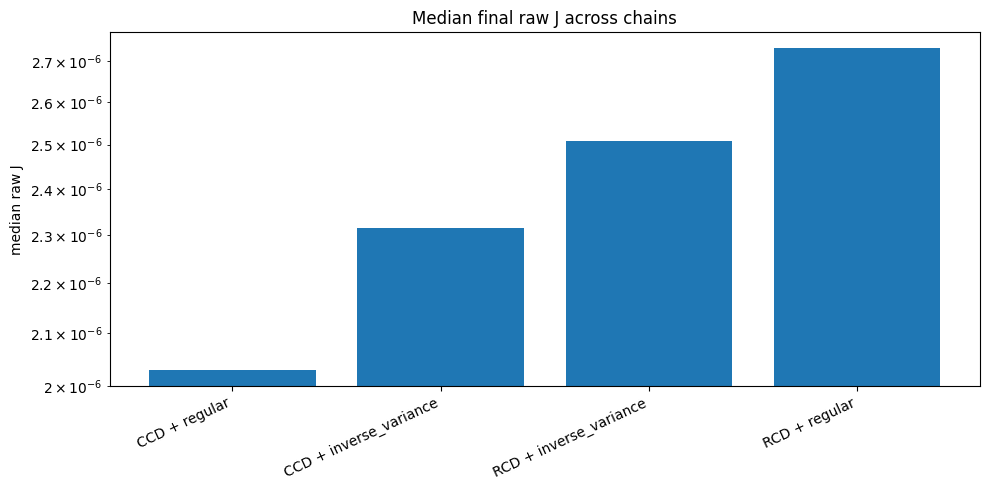

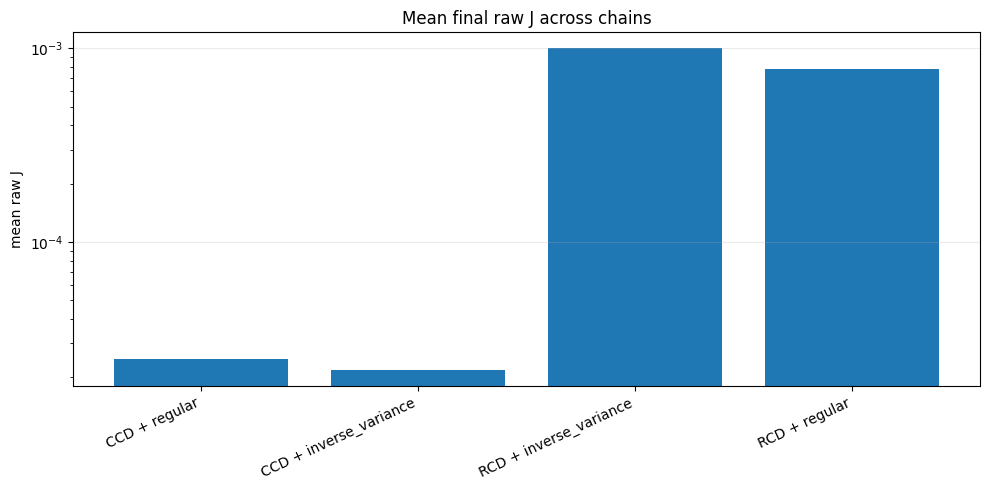

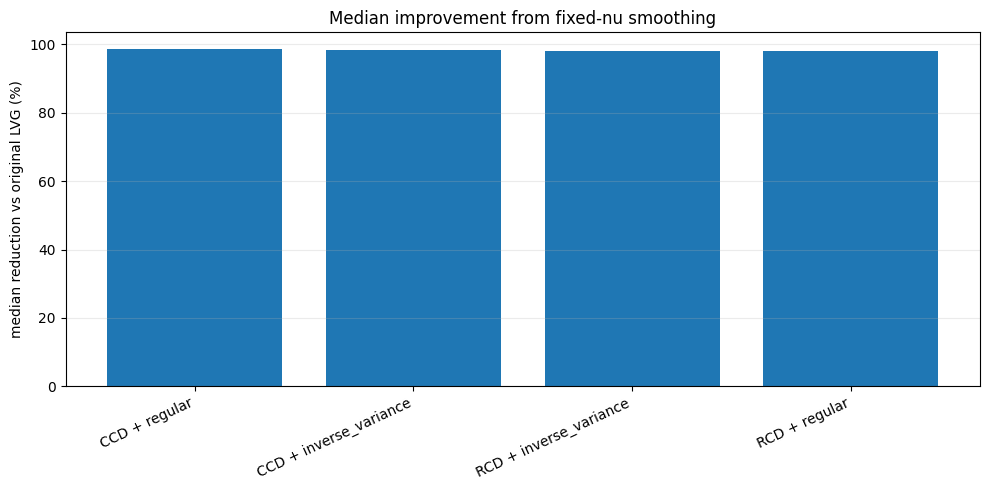

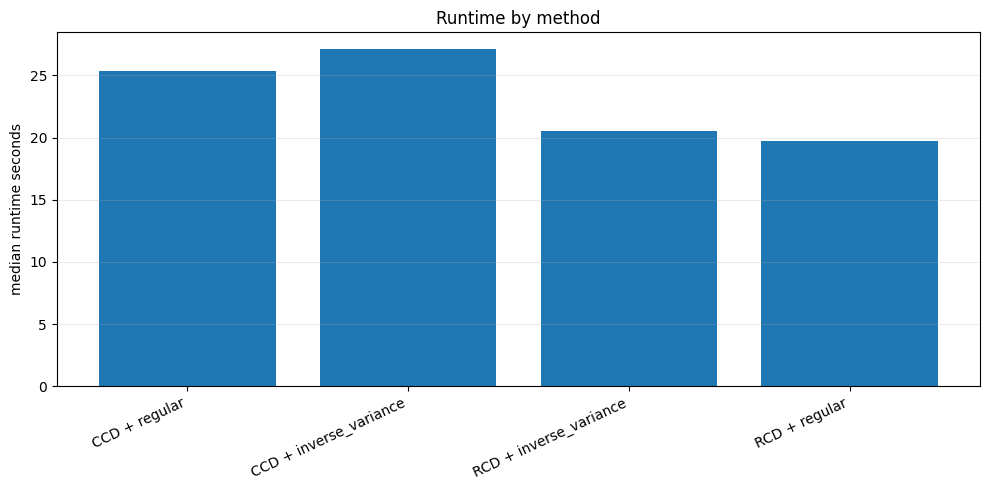

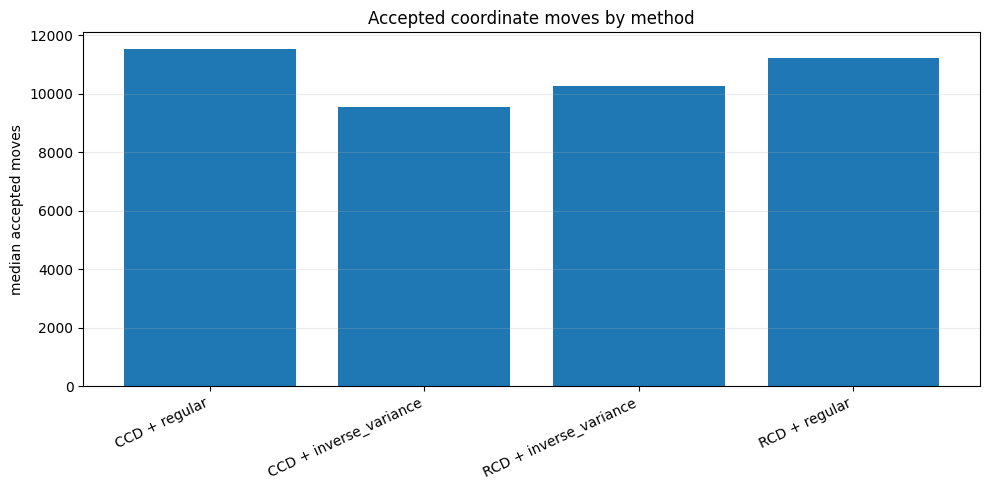

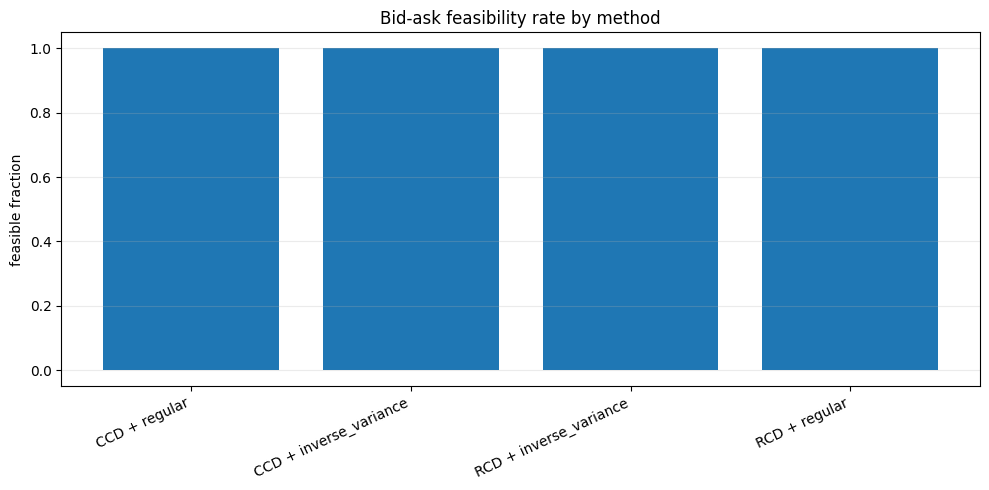

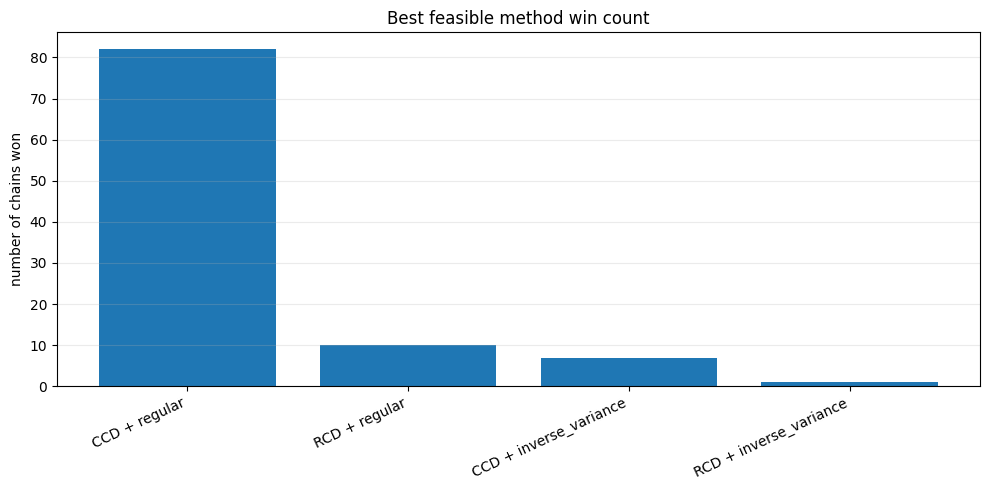

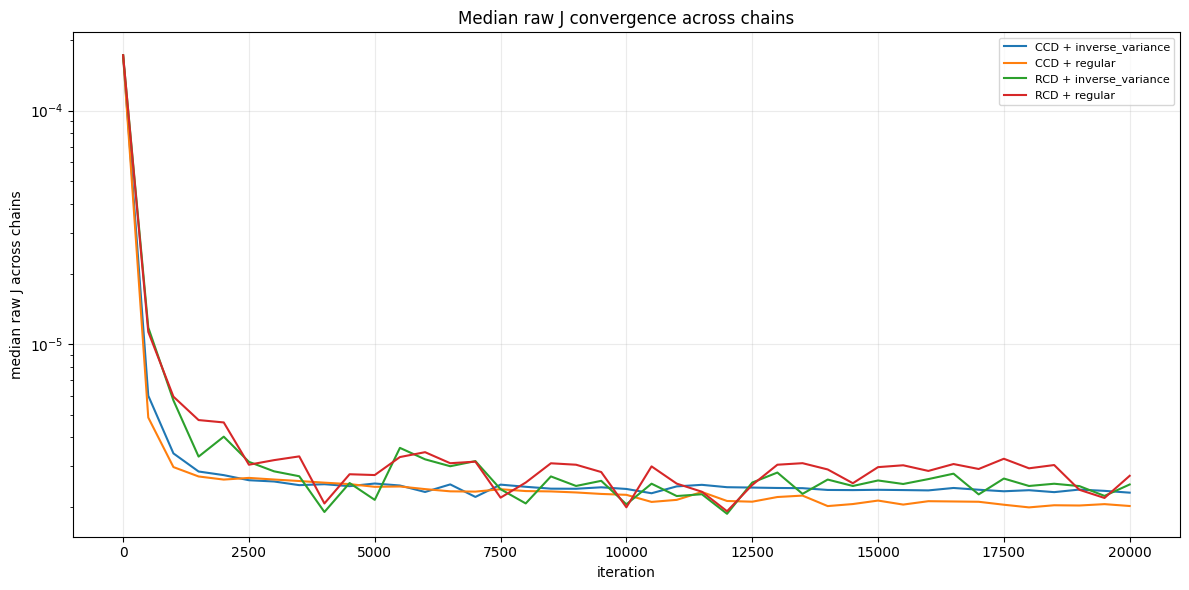

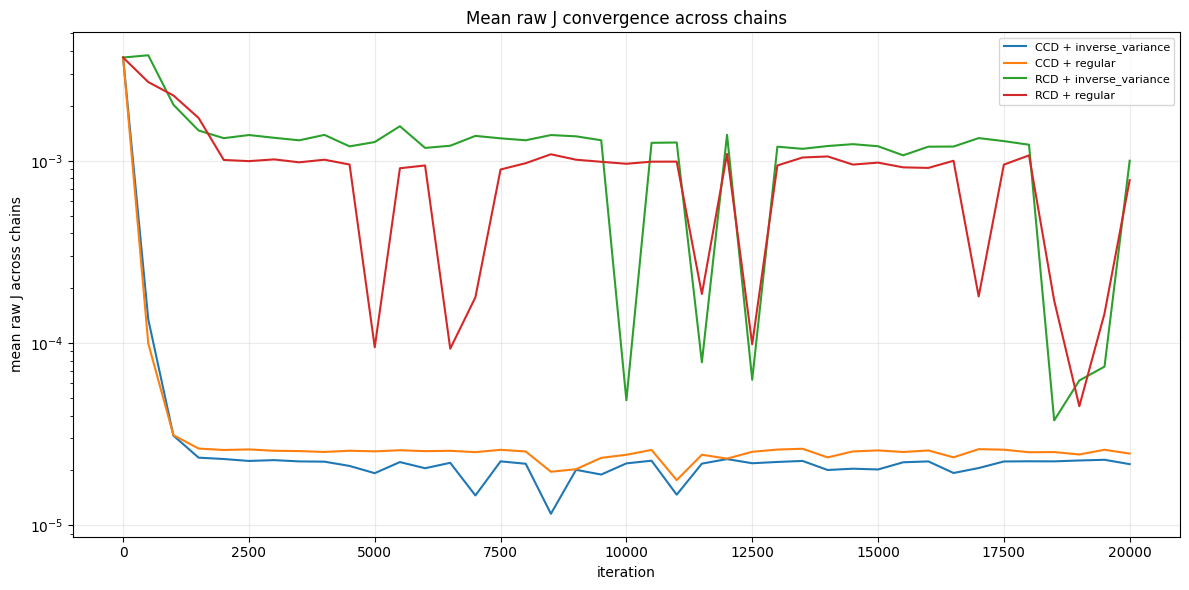

In [55]:
def method_label(descent_method, proxy_kind):
    return f"{descent_method} + {proxy_kind}"


def add_method_label(df):
    out = df.copy()
    out["method_label"] = out.apply(lambda r: method_label(r["descent_method"], r["proxy_kind"]), axis=1)
    return out


def plot_fixed_nu_summary(summary_df, best_by_chain, traces):
    plot_data = add_method_label(summary_df)

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["median_raw_J"])
    plt.yscale("log")
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("median raw J")
    plt.title("Median final raw J across chains")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_median_raw_J_by_method.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["mean_raw_J"])
    plt.yscale("log")
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("mean raw J")
    plt.title("Mean final raw J across chains")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_mean_raw_J_by_method.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["median_reduction_vs_original_pct"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("median reduction vs original LVG (%)")
    plt.title("Median improvement from fixed-nu smoothing")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_reduction_vs_original.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["median_runtime_seconds"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("median runtime seconds")
    plt.title("Runtime by method")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_runtime_by_method.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["median_accepted_moves"])
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("median accepted moves")
    plt.title("Accepted coordinate moves by method")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_accepted_moves_by_method.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(plot_data["method_label"], plot_data["feasible_rate"])
    plt.ylim(-0.05, 1.05)
    plt.xticks(rotation=25, ha="right")
    plt.ylabel("feasible fraction")
    plt.title("Bid-ask feasibility rate by method")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_feasibility_by_method.png", dpi=150)
    plt.show()

    if not best_by_chain.empty:
        wins = add_method_label(best_by_chain).groupby("method_label").size().sort_values(ascending=False)
        plt.figure(figsize=(10, 5))
        plt.bar(wins.index, wins.values)
        plt.xticks(rotation=25, ha="right")
        plt.ylabel("number of chains won")
        plt.title("Best feasible method win count")
        plt.grid(True, axis="y", alpha=0.25)
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / "fixed_nu_100_win_counts.png", dpi=150)
        plt.show()

    if traces.empty:
        print("No convergence traces available.")
        return
    trace_data = add_method_label(traces)
    plt.figure(figsize=(12, 6))
    for label, group in trace_data.groupby("method_label"):
        grouped = group.groupby("iteration", as_index=False)["raw_J"].median().sort_values("iteration")
        plt.plot(grouped["iteration"], grouped["raw_J"], label=label)
    plt.yscale("log")
    plt.xlabel("iteration")
    plt.ylabel("median raw J across chains")
    plt.title("Median raw J convergence across chains")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_convergence_raw_J.png", dpi=150)
    plt.show()

    plt.figure(figsize=(12, 6))
    for label, group in trace_data.groupby("method_label"):
        grouped = group.groupby("iteration", as_index=False)["raw_J"].mean().sort_values("iteration")
        plt.plot(grouped["iteration"], grouped["raw_J"], label=label)
    plt.yscale("log")
    plt.xlabel("iteration")
    plt.ylabel("mean raw J across chains")
    plt.title("Mean raw J convergence across chains")
    plt.grid(True, alpha=0.25)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_convergence_raw_J_mean.png", dpi=150)
    plt.show()

plot_fixed_nu_summary(fixed_nu_summary, best_methods_by_chain, fixed_nu_traces)


Recomputing representative theta curves for date=20111005, exdate=20120922


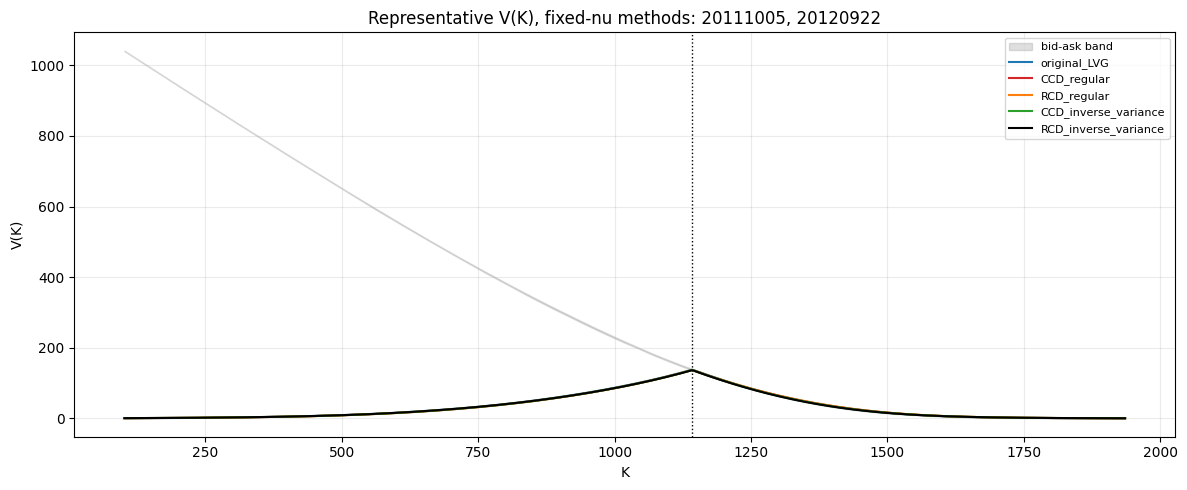

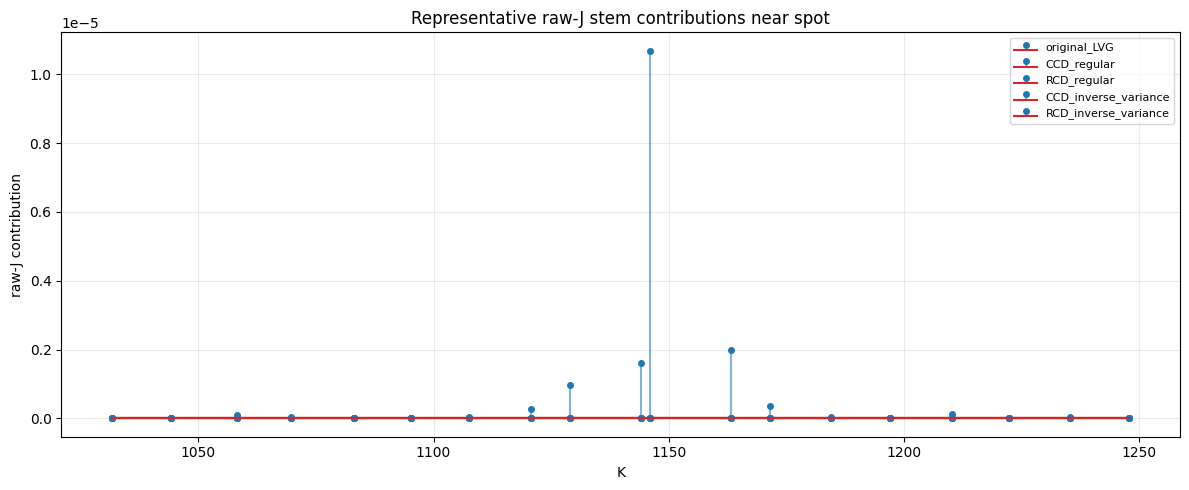

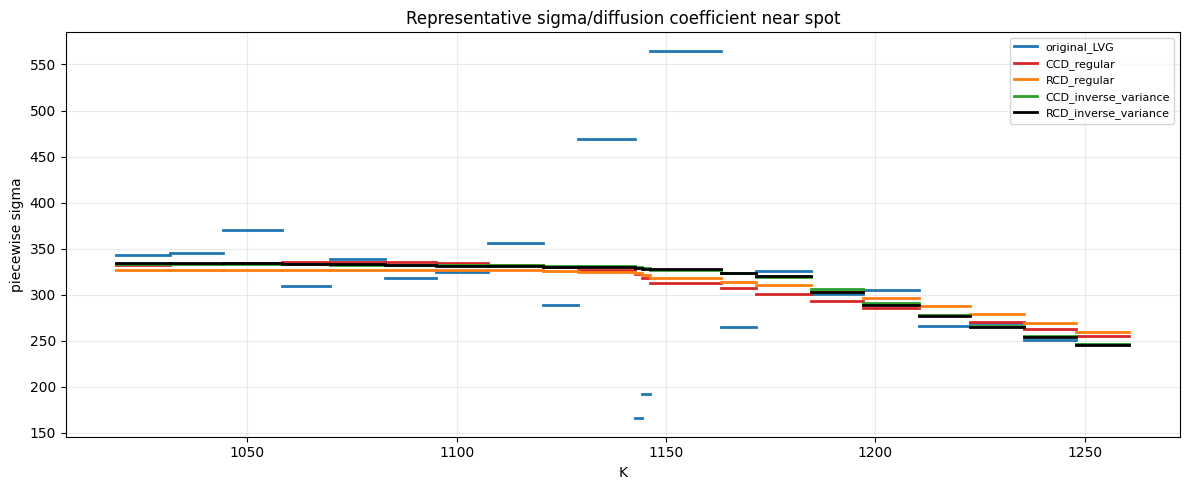

In [56]:
def unique_methods(methods):
    seen = set()
    output = []
    for method in methods:
        if method not in seen:
            seen.add(method)
            output.append(method)
    return output


def plot_sigma_piecewise(R1, R2, S0, theta, label, color=None, k_low=None, k_high=None):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    endpoints = np.concatenate([left_nu, [S0], right_nu])
    sigmas = np.concatenate([left_sigma, right_sigma])
    first = True
    for i, sigma in enumerate(sigmas):
        x0 = endpoints[i]
        x1 = endpoints[i + 1]
        if k_low is not None and x1 < k_low:
            continue
        if k_high is not None and x0 > k_high:
            continue
        plt.plot([x0, x1], [sigma, sigma], color=color, linewidth=2, label=label if first else None)
        first = False


def compute_representative_thetas(date, exdate):
    chain = build_adjusted_chain(raw_spx, int(date), int(exdate), MIN_STRIKES)
    rows, traces, theta_store = run_one_chain_fixed_nu_comparison(chain)
    return chain, theta_store


def plot_representative_fixed_nu_chain(results):
    feasible = results[results["bid_ask_feasible"]].sort_values("raw_J")
    if feasible.empty:
        print("No feasible representative result.")
        return

    best = feasible.iloc[0]
    date = int(best.date)
    exdate = int(best.exdate)
    print(f"Recomputing representative theta curves for date={date}, exdate={exdate}")
    chain, theta_store = compute_representative_thetas(date, exdate)

    methods = unique_methods(["original_LVG", "CCD_regular", "RCD_regular", "CCD_inverse_variance", "RCD_inverse_variance", best.method])
    K_grid = np.linspace(chain["K"].min(), chain["K"].max(), 500)
    colors = {
        "original_LVG": "tab:blue",
        "CCD_regular": "tab:red",
        "RCD_regular": "tab:orange",
        "CCD_inverse_variance": "tab:green",
        "RCD_inverse_variance": "black",
    }

    plt.figure(figsize=(12, 5))
    plt.fill_between(chain["K"], chain["bid"], chain["ask"], color="gray", alpha=0.25, label="bid-ask band")
    for method in methods:
        if method not in theta_store:
            continue
        R1, R2, theta = theta_store[method]
        c_v1, c_v2 = load_c_values(R1, R2, chain["S0"], theta)
        V = np.array([V_K(k, R1, R2, chain["S0"], theta, c_v1, c_v2) for k in K_grid])
        plt.plot(K_grid, V, label=method, color=colors.get(method))
    plt.axvline(chain["S0"], color="black", linestyle=":", linewidth=1)
    plt.xlabel("K")
    plt.ylabel("V(K)")
    plt.title(f"Representative V(K), fixed-nu methods: {date}, {exdate}")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_representative_V_curves.png", dpi=150)
    plt.show()

    plt.figure(figsize=(12, 5))
    for method in methods:
        if method not in theta_store:
            continue
        R1, R2, theta = theta_store[method]
        jumps = jump_contributions_by_knot(R1, R2, chain["S0"], theta)
        keep = (jumps["knot"] >= chain["S0"] * 0.9) & (jumps["knot"] <= chain["S0"] * 1.1)
        markerline, stemlines, baseline = plt.stem(jumps.loc[keep, "knot"], jumps.loc[keep, "jump_squared"], label=method)
        plt.setp(stemlines, alpha=0.55)
        plt.setp(markerline, markersize=4)
    plt.xlabel("K")
    plt.ylabel("raw-J contribution")
    plt.title("Representative raw-J stem contributions near spot")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_representative_raw_J_stems.png", dpi=150)
    plt.show()

    plt.figure(figsize=(12, 5))
    k_low = chain["S0"] * 0.9
    k_high = chain["S0"] * 1.1
    for method in methods:
        if method not in theta_store:
            continue
        R1, R2, theta = theta_store[method]
        plot_sigma_piecewise(R1, R2, chain["S0"], theta, method, colors.get(method), k_low, k_high)
    plt.xlabel("K")
    plt.ylabel("piecewise sigma")
    plt.title("Representative sigma/diffusion coefficient near spot")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "fixed_nu_100_representative_sigma_curves.png", dpi=150)
    plt.show()

plot_representative_fixed_nu_chain(fixed_nu_results)


## Step 9: maturity-bucket diagnostic for regular CCD vs inverse-variance CCD

The mean and median conclusions point in different directions for `CCD_regular` versus `CCD_inverse_variance`. The mean raw `J` is slightly lower for inverse variance, while the median raw `J` and win count favor regular CCD.

That means the comparison should be treated as a **paired chain-level problem**. For each chain, compare

$$
\Delta_i = J_i^{\mathrm{inv}} - J_i^{\mathrm{regular}}.
$$

If `Delta_i < 0`, inverse variance won on that chain. If `Delta_i > 0`, regular CCD won. We also look at the ratio

$$
\rho_i = \frac{J_i^{\mathrm{inv}}}{J_i^{\mathrm{regular}}}.
$$

Ratios are useful because raw `J` can vary by orders of magnitude across chains. A ratio below 1 means inverse variance improved on that chain; a ratio above 1 means regular CCD was better.

This section answers three questions:

1. Which maturity buckets produced the inverse-variance wins?
2. How large were those wins?
3. Are the inverse-variance wins broad and systematic, or concentrated in a small subset of chains?


In [ ]:
PAIRWISE_DIAGNOSTIC_DIR = OUTPUT_DIR / "paired_regular_vs_inverse_diagnostics"
PAIRWISE_DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)


def paired_regular_inverse_table(results):
    fixed = results[results["method_family"] == "fixed_nu_descent"].copy()
    original = results[results["method"] == "original_LVG"][[
        "date", "exdate", "T", "maturity_bucket", "raw_J", "R1", "R2", "R_total"
    ]].rename(columns={"raw_J": "original_J"})

    pivot = fixed.pivot_table(
        index=["date", "exdate"],
        columns="method",
        values="raw_J",
        aggfunc="first",
    ).reset_index()

    paired = original.drop_duplicates(["date", "exdate"]).merge(pivot, on=["date", "exdate"])
    paired["inv_minus_reg"] = paired["CCD_inverse_variance"] - paired["CCD_regular"]
    paired["inv_over_reg"] = paired["CCD_inverse_variance"] / paired["CCD_regular"]
    paired["inv_improvement_vs_reg_pct"] = 100.0 * (
        paired["CCD_regular"] - paired["CCD_inverse_variance"]
    ) / paired["CCD_regular"]
    paired["winner"] = np.where(paired["inv_minus_reg"] < 0, "inverse_variance", "regular")
    return paired


paired_regular_inverse = paired_regular_inverse_table(fixed_nu_results)
paired_regular_inverse.to_csv(PAIRWISE_DIAGNOSTIC_DIR / "paired_CCD_regular_vs_inverse.csv", index=False)

bucket_summary = (
    paired_regular_inverse.groupby("maturity_bucket", as_index=False)
    .agg(
        chains=("date", "count"),
        inverse_wins=("winner", lambda s: int((s == "inverse_variance").sum())),
        regular_wins=("winner", lambda s: int((s == "regular").sum())),
        median_inverse_over_regular=("inv_over_reg", "median"),
        mean_inverse_over_regular=("inv_over_reg", "mean"),
        median_inverse_improvement_pct=("inv_improvement_vs_reg_pct", "median"),
        mean_inverse_improvement_pct=("inv_improvement_vs_reg_pct", "mean"),
    )
)
bucket_summary.to_csv(PAIRWISE_DIAGNOSTIC_DIR / "maturity_bucket_CCD_regular_vs_inverse_summary.csv", index=False)

inverse_winners = paired_regular_inverse[paired_regular_inverse["winner"] == "inverse_variance"].copy()
inverse_winners = inverse_winners.sort_values("inv_improvement_vs_reg_pct", ascending=False)
inverse_winners.to_csv(PAIRWISE_DIAGNOSTIC_DIR / "inverse_variance_winning_chains.csv", index=False)

print("Maturity-bucket summary: CCD inverse-variance versus CCD regular")
display(bucket_summary)

print("Chains where CCD inverse-variance beat CCD regular")
show_cols = [
    "date", "exdate", "T", "maturity_bucket", "R1", "R2", "original_J",
    "CCD_regular", "CCD_inverse_variance", "inv_over_reg", "inv_improvement_vs_reg_pct",
]
display(inverse_winners[show_cols])

# Pull all four method rows for the inverse-winning chains so we can diagnose whether
# inverse variance won only relative to CCD regular or whether another method was better.
inverse_keys = inverse_winners[["date", "exdate"]]
inverse_winner_method_rows = (
    fixed_nu_results[fixed_nu_results["method_family"] == "fixed_nu_descent"]
    .merge(inverse_keys, on=["date", "exdate"])
    .sort_values(["date", "exdate", "raw_J"])
)
inverse_winner_method_rows.to_csv(PAIRWISE_DIAGNOSTIC_DIR / "method_rows_for_inverse_winning_chains.csv", index=False)
print("All method rows on the inverse-winning chains")
display(inverse_winner_method_rows[[
    "date", "exdate", "maturity_bucket", "method", "raw_J", "reduction_vs_original_pct",
    "runtime_seconds", "accepted_moves", "min_quote_slack", "regular_proxy", "inverse_variance_proxy",
]])

# Plot inverse-win counts by maturity bucket.
plt.figure(figsize=(9, 5))
plt.bar(bucket_summary["maturity_bucket"], bucket_summary["inverse_wins"], label="inverse wins")
plt.bar(bucket_summary["maturity_bucket"], bucket_summary["regular_wins"], bottom=bucket_summary["inverse_wins"], alpha=0.35, label="regular wins")
plt.ylabel("number of chains")
plt.title("CCD regular vs CCD inverse-variance wins by maturity bucket")
plt.grid(True, axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PAIRWISE_DIAGNOSTIC_DIR / "wins_by_maturity_bucket.png", dpi=150)
plt.show()

# Plot ratios by maturity bucket. Values below 1 favor inverse variance.
plt.figure(figsize=(10, 5))
ordered_buckets = ["short", "medium", "long", "very_long"]
data = [paired_regular_inverse.loc[paired_regular_inverse["maturity_bucket"] == b, "inv_over_reg"] for b in ordered_buckets]
plt.boxplot(data, labels=ordered_buckets, showfliers=True)
plt.axhline(1.0, color="black", linestyle=":", linewidth=1)
plt.ylabel("CCD inverse raw J / CCD regular raw J")
plt.title("Paired method ratio by maturity bucket")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(PAIRWISE_DIAGNOSTIC_DIR / "inverse_over_regular_ratio_by_bucket.png", dpi=150)
plt.show()

# Plot how large the inverse wins were.
if len(inverse_winners) > 0:
    labels = inverse_winners["date"].astype(str) + "\n" + inverse_winners["exdate"].astype(str)
    plt.figure(figsize=(11, 5))
    plt.bar(labels, inverse_winners["inv_improvement_vs_reg_pct"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("inverse improvement vs regular CCD (%)")
    plt.title("How much better inverse variance was on its winning chains")
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(PAIRWISE_DIAGNOSTIC_DIR / "inverse_win_magnitudes.png", dpi=150)
    plt.show()

print("Diagnostic files saved to", PAIRWISE_DIAGNOSTIC_DIR)


## Step 10: original `Quotes.csv` four-method comparison

The 100-chain benchmark uses many SPX chains from the WRDS-style file. This local section repeats the same four-method fixed-nu comparison on the original single-chain dataset used earlier in the project: `Quotes.csv`.

This is useful because it connects the large-sample benchmark back to the chain where we developed the initial diagnostics. The experiment is intentionally localized:

- it does not overwrite the 100-chain results,
- it writes separate `original_quotes_*` output files,
- it uses the same four methods as the benchmark,
- it keeps the original nus fixed and only changes sigmas.

The four methods are again:

1. `CCD_regular`,
2. `RCD_regular`,
3. `CCD_inverse_variance`,
4. `RCD_inverse_variance`.

As before, the proxy guides the coordinate updates, but raw `J` is the final comparison metric.


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


Original Quotes.csv fixed-nu four-method comparison:


,method,raw_J,reduction_vs_original_pct,runtime_seconds,accepted_moves,bid_ask_feasible,min_quote_slack,regular_proxy,inverse_variance_proxy
3,CCD_inverse_variance,2.761455e-07,99.980656,21.382704,11161.0,True,-9.901429e-08,39.253759,1.869045e-08
4,RCD_inverse_variance,4.027766e-07,99.971786,14.289345,10109.0,True,-9.876109e-08,61.212668,2.342196e-08
1,CCD_regular,1.037782e-06,99.927304,21.731218,13638.0,True,-9.536815e-08,29.975942,3.780639e-08
2,RCD_regular,1.591070e-06,99.888546,12.426026,12549.0,True,-3.169407e-08,54.151962,4.817714e-08
0,original_LVG,1.427559e-03,0.000000,NaN,NaN,True,1.577017e-02,257058.884176,1.862739e-05


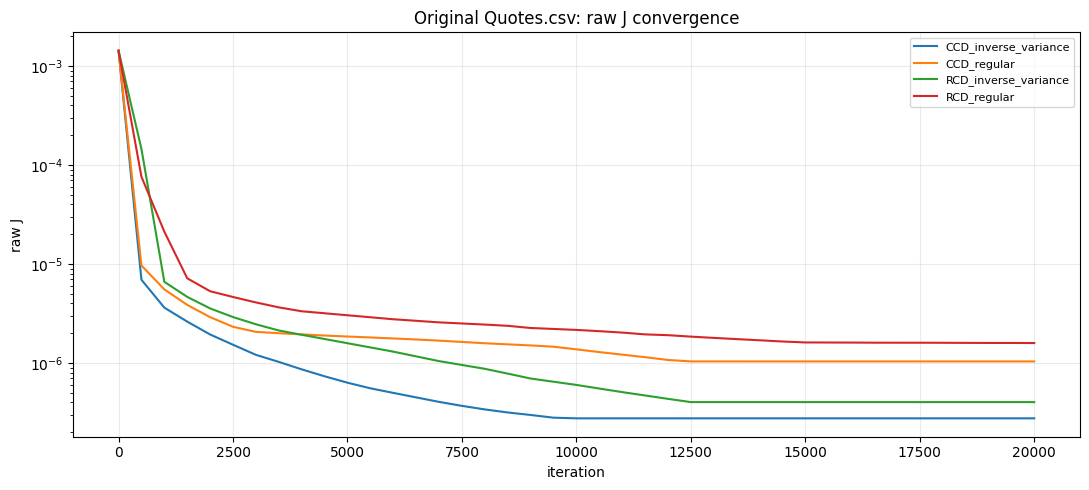

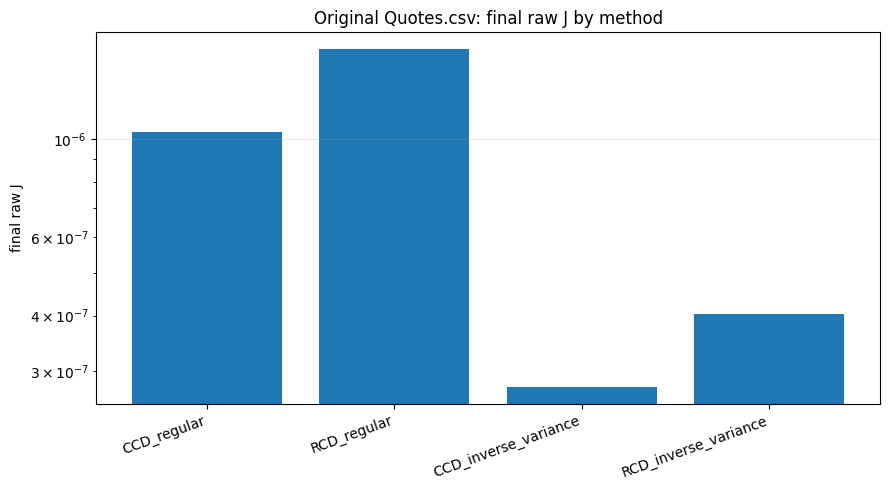

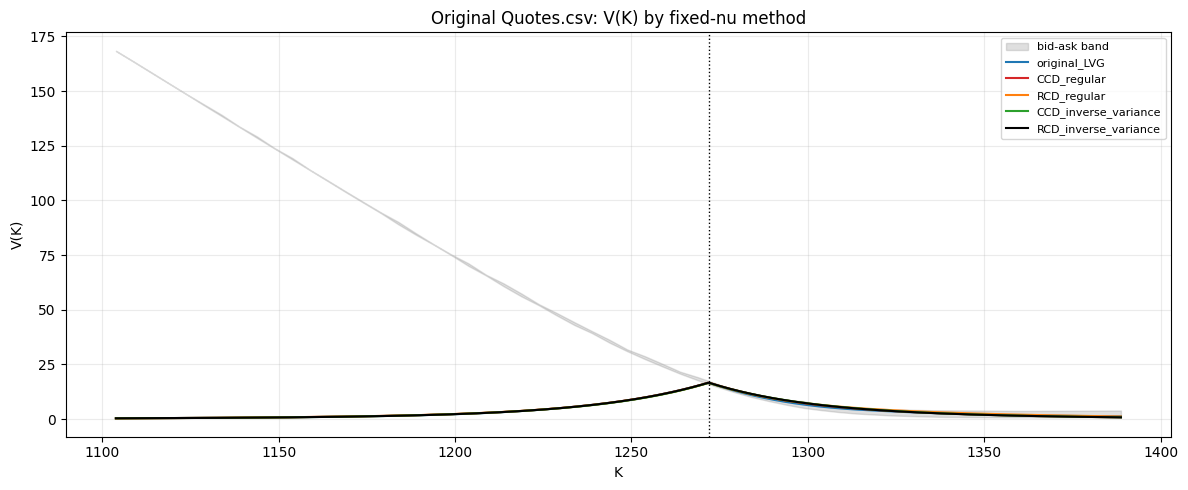

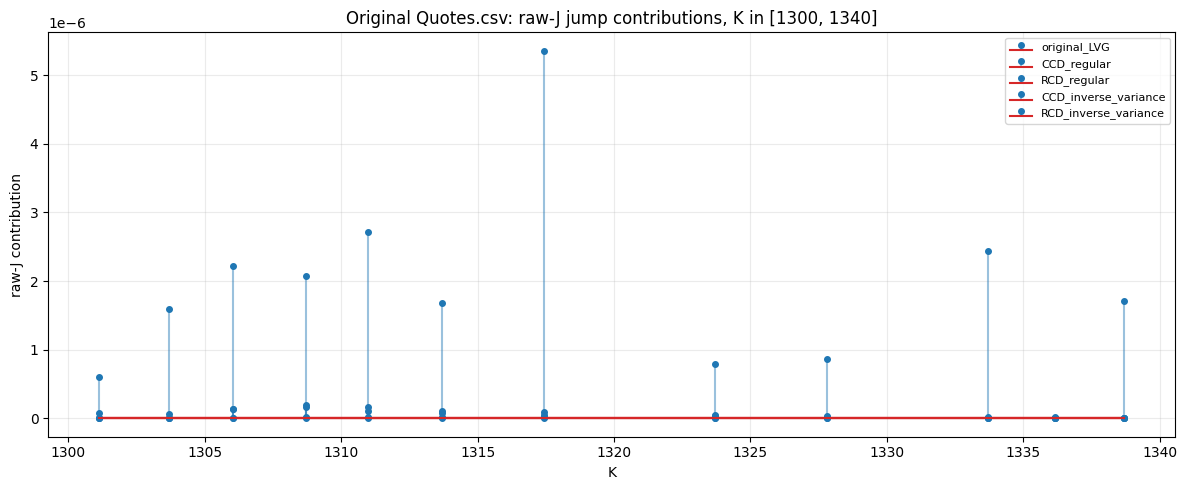

In [57]:
ORIGINAL_QUOTES_OUTPUT_DIR = OUTPUT_DIR / "original_quotes_single_chain"
ORIGINAL_QUOTES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORIGINAL_QUOTES_ITERATIONS = 20000
ORIGINAL_QUOTES_RECORD_EVERY = 500
ORIGINAL_QUOTES_S0 = 1271.87


def load_original_quotes_chain(file_name="Quotes.csv", S0=ORIGINAL_QUOTES_S0):
    path = find_data_file(file_name)
    quotes = pd.read_csv(path, header=None, names=["K", "ask", "bid"])
    quotes = quotes.sort_values("K").reset_index(drop=True)

    K = quotes["K"].to_numpy(dtype=float)
    ask = quotes["ask"].to_numpy(dtype=float)
    bid = quotes["bid"].to_numpy(dtype=float)
    keep = np.isfinite(K) & np.isfinite(bid) & np.isfinite(ask) & (ask >= bid)

    K = K[keep]
    bid = bid[keep]
    ask = ask[keep]

    return {
        "date": "original_quotes",
        "exdate": "single_chain",
        "T": np.nan,
        "D": 1.0,
        "F": float(S0),
        "S0": float(S0),
        "K": K,
        "bid": bid,
        "ask": ask,
        "bid_ask": np.column_stack([K, bid, ask]),
    }


def run_original_quotes_fixed_nu_comparison():
    chain = load_original_quotes_chain()
    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    baseline_J = J_value(R1, R2, chain["S0"], init_theta)

    rows = []
    traces = []
    theta_store = {"original_LVG": (R1, R2, init_theta)}

    rows.append(result_row(
        "original_LVG", chain, R1, R2, init_theta, baseline_J,
        extra={
            "method_family": "original_quotes",
            "proxy_kind": "none",
            "update_order": "none",
            "descent_method": "none",
            "accepted_moves": np.nan,
            "iterations": 0,
        },
    ))

    for proxy_kind in ["regular", "inverse_variance"]:
        for update_order in ["cyclic", "random"]:
            descent_method = ORDER_LABELS[update_order]
            method = f"{descent_method}_{proxy_kind}"
            start = time.time()
            theta_final, trace, accepted_moves = coordinate_descent_sigma(
                R1,
                R2,
                chain["S0"],
                init_theta,
                chain["bid_ask"],
                proxy_kind=proxy_kind,
                update_order=update_order,
                num_iterations=ORIGINAL_QUOTES_ITERATIONS,
                random_seed=RANDOM_SEED,
                record_every=ORIGINAL_QUOTES_RECORD_EVERY,
            )
            runtime = time.time() - start
            rows.append(result_row(
                method, chain, R1, R2, theta_final, baseline_J, runtime,
                extra={
                    "method_family": "original_quotes_fixed_nu_descent",
                    "proxy_kind": proxy_kind,
                    "update_order": update_order,
                    "descent_method": descent_method,
                    "accepted_moves": accepted_moves,
                    "iterations": ORIGINAL_QUOTES_ITERATIONS,
                },
            ))
            trace = trace.copy()
            trace["method"] = method
            trace["proxy_kind"] = proxy_kind
            trace["update_order"] = update_order
            trace["descent_method"] = descent_method
            traces.append(trace)
            theta_store[method] = (R1, R2, theta_final)

    results = pd.DataFrame(rows)
    convergence = pd.concat(traces, ignore_index=True)
    return chain, results, convergence, theta_store


original_quotes_chain, original_quotes_results, original_quotes_convergence, original_quotes_thetas = run_original_quotes_fixed_nu_comparison()

original_quotes_results.to_csv(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_four_method_results.csv", index=False)
original_quotes_convergence.to_csv(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_four_method_convergence.csv", index=False)

comparison_cols = [
    "method", "raw_J", "reduction_vs_original_pct", "runtime_seconds",
    "accepted_moves", "bid_ask_feasible", "min_quote_slack",
    "regular_proxy", "inverse_variance_proxy",
]
print("Original Quotes.csv fixed-nu four-method comparison:")
display(original_quotes_results[comparison_cols].sort_values("raw_J"))

# Convergence plot.
plt.figure(figsize=(11, 5))
for method, group in original_quotes_convergence.groupby("method"):
    group = group.sort_values("iteration")
    plt.plot(group["iteration"], group["raw_J"], label=method)
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("raw J")
plt.title("Original Quotes.csv: raw J convergence")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_raw_J_convergence.png", dpi=150)
plt.show()

# Final raw-J bar chart.
plot_data = original_quotes_results[original_quotes_results["method"] != "original_LVG"].copy()
plt.figure(figsize=(9, 5))
plt.bar(plot_data["method"], plot_data["raw_J"])
plt.yscale("log")
plt.xticks(rotation=20, ha="right")
plt.ylabel("final raw J")
plt.title("Original Quotes.csv: final raw J by method")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_final_raw_J_by_method.png", dpi=150)
plt.show()

# V(K) comparison.
K_grid = np.linspace(original_quotes_chain["K"].min(), original_quotes_chain["K"].max(), 500)
colors = {
    "original_LVG": "tab:blue",
    "CCD_regular": "tab:red",
    "RCD_regular": "tab:orange",
    "CCD_inverse_variance": "tab:green",
    "RCD_inverse_variance": "black",
}
plt.figure(figsize=(12, 5))
plt.fill_between(
    original_quotes_chain["K"],
    original_quotes_chain["bid"],
    original_quotes_chain["ask"],
    color="gray",
    alpha=0.25,
    label="bid-ask band",
)
for method, (R1, R2, theta) in original_quotes_thetas.items():
    c_v1, c_v2 = load_c_values(R1, R2, original_quotes_chain["S0"], theta)
    V = np.array([V_K(k, R1, R2, original_quotes_chain["S0"], theta, c_v1, c_v2) for k in K_grid])
    plt.plot(K_grid, V, label=method, color=colors.get(method))
plt.axvline(original_quotes_chain["S0"], color="black", linestyle=":", linewidth=1)
plt.xlabel("K")
plt.ylabel("V(K)")
plt.title("Original Quotes.csv: V(K) by fixed-nu method")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_V_curves.png", dpi=150)
plt.show()

# Raw-J stem comparison near the right wing problem area from the original experiment.
plt.figure(figsize=(12, 5))
for method, (R1, R2, theta) in original_quotes_thetas.items():
    jumps = jump_contributions_by_knot(R1, R2, original_quotes_chain["S0"], theta)
    keep = (jumps["knot"] >= 1300.0) & (jumps["knot"] <= 1340.0)
    markerline, stemlines, baseline = plt.stem(
        jumps.loc[keep, "knot"],
        jumps.loc[keep, "jump_squared"],
        label=method,
    )
    plt.setp(stemlines, alpha=0.45)
    plt.setp(markerline, markersize=4)
plt.xlabel("K")
plt.ylabel("raw-J contribution")
plt.title("Original Quotes.csv: raw-J jump contributions, K in [1300, 1340]")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(ORIGINAL_QUOTES_OUTPUT_DIR / "original_quotes_raw_J_stems_1300_1340.png", dpi=150)
plt.show()


## Step 11: conclusion checklist

The 100-chain test supports the following conclusions.

**Main empirical conclusion:** deterministic CCD with the regular adjacent-sigma proxy is the strongest fixed-nu method in this experiment. It won the largest number of chains and had the best median reduction in raw `J`.

**Why this matters:** the inverse-variance proxy is mathematically motivated by one part of the raw jump formula, but it did not generally produce lower raw `J`. This tells us that optimizing only

$$
\frac{1}{\sigma_{i+1}^2}-\frac{1}{\sigma_i^2}
$$

misses important parts of the full LVG jump expression, including the exponential coefficients and local level of the time-value curve.

**RCD conclusion:** random coordinate descent was usually faster, but it was less reliable and usually finished with larger raw `J`. For this fixed-nu problem, the deterministic cyclic structure appears useful rather than arbitrary.

**Feasibility conclusion:** all four methods preserved bid-ask feasibility in the 100-chain run, so the comparison is fair: the lower raw `J` values are not coming from violating market constraints.

**Next research step:** fixed-nu smoothing is now well understood. Further improvement should come from adaptive nu placement or added-nu models, not from switching the fixed-nu proxy alone.


## Step 12: full-theta augmented-Lagrangian polish after CCD

The previous sections compare fixed-nu CCD/RCD methods. This section asks a different question:

> After running the strongest fixed-nu method, can an augmented-Lagrangian optimizer improve the full LVG parameter vector \(\theta\)?

The starting point is always the feasible output of **20,000 iterations of CCD with the regular adjacent-sigma proxy**. From there, the augmented-Lagrangian polish is allowed to move both the knot locations \(\nu\) and the diffusion coefficients \(\sigma\).

This is different from the earlier CCD tests:

- CCD moves only sigmas and rejects any step that leaves the bid-ask band.
- Augmented Lagrangian optimizes a larger parameter vector and allows the inner optimizer to explore points that may temporarily violate bid-ask.
- The multiplier and penalty terms push the final answer back toward feasibility.
- A result only counts as an improvement if the final theta is bid-ask feasible and has lower raw \(J\) than the CCD start.

For each quote strike \(K_i\), define the bid and ask violations:

$$
v_i^{bid}(\theta)=\max(bid_i-C_\theta(K_i),0),
$$

$$
v_i^{ask}(\theta)=\max(C_\theta(K_i)-ask_i,0).
$$

The augmented objective is

$$
L(\theta)=J(\theta)+\lambda_{bid}\cdot v^{bid}(\theta)
+\lambda_{ask}\cdot v^{ask}(\theta)
+\frac{\rho}{2}\left(\|v^{bid}(\theta)\|^2+\|v^{ask}(\theta)\|^2\right).
$$

After each outer iteration, the multipliers are updated by

$$
\lambda_{bid}\leftarrow \max(0,\lambda_{bid}+\rho v^{bid}),
$$

$$
\lambda_{ask}\leftarrow \max(0,\lambda_{ask}+\rho v^{ask}).
$$

Because this version moves nus, the optimizer works in a raw variable space. Positive gaps reconstruct ordered nus below and above spot, and positive sigma variables reconstruct sigmas. This means the structural LVG constraints are always satisfied by construction; bid-ask feasibility is checked separately at the end.


In [59]:
from scipy.optimize import minimize

AL_FULL_OUTPUT_DIR = OUTPUT_DIR / "augmented_lagrangian_full_theta_polish"
AL_FULL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Change to "one_chain" for a fast smoke test, or "twelve_chains" for the planned run.
AL_FULL_RUN_MODE = "twelve_chains"
AL_CHAINS_PER_BUCKET = 3
AL_CCD_START_ITERATIONS = 20000
AL_J_SCALE = 1e8
AL_RHO_INIT = 1e4
AL_RHO_SCALE = 5.0
AL_RHO_MAX = 1e12
AL_OUTER_ITERATIONS = 6
AL_INNER_MAXITER = 35
AL_RAW_BOUND = 20.0
AL_FEAS_TOL = 1e-7
AL_POSITIVE_FLOOR = 1e-8


def positive_from_raw(raw):
    """Map raw values to positive values without using softplus."""
    return np.exp(np.clip(raw, -AL_RAW_BOUND, AL_RAW_BOUND)) + AL_POSITIVE_FLOOR


def raw_from_positive(values):
    """Inverse of positive_from_raw, up to the small positive floor."""
    values = np.asarray(values, dtype=float)
    return np.log(np.maximum(values - AL_POSITIVE_FLOOR, AL_POSITIVE_FLOOR))


def full_theta_to_raw(R1, R2, S0, theta):
    """Convert feasible theta into raw gaps and raw sigmas."""
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)

    left_gaps = np.concatenate([left_nu[1:] - left_nu[:-1], [S0 - left_nu[-1]]])
    right_gaps = np.concatenate([[right_nu[0] - S0], right_nu[1:] - right_nu[:-1]])

    if np.any(left_gaps <= 0) or np.any(right_gaps <= 0):
        raise ValueError("Cannot build raw variables from unordered nus")
    if np.any(left_sigma <= 0) or np.any(right_sigma <= 0):
        raise ValueError("Cannot build raw variables from nonpositive sigmas")

    return np.concatenate([
        raw_from_positive(left_gaps),
        raw_from_positive(left_sigma),
        raw_from_positive(right_gaps),
        raw_from_positive(right_sigma),
    ])


def full_theta_from_raw(R1, R2, S0, raw):
    """Reconstruct theta from raw gaps and sigmas. Nus are ordered by construction."""
    raw = np.asarray(raw, dtype=float)
    i = 0
    left_gaps = positive_from_raw(raw[i:i + R1]); i += R1
    left_sigma = positive_from_raw(raw[i:i + R1]); i += R1
    right_gaps = positive_from_raw(raw[i:i + R2]); i += R2
    right_sigma = positive_from_raw(raw[i:i + R2]); i += R2

    left_suffix = np.flip(np.cumsum(np.flip(left_gaps)))
    left_nu = S0 - left_suffix
    right_nu = S0 + np.cumsum(right_gaps)

    return theta_from_parts(left_nu, left_sigma, right_nu, right_sigma)


def max_bid_ask_violation(R1, R2, S0, theta, bid_ask_arr):
    """Positive max violation; zero means inside the bid-ask band."""
    try:
        prices = model_prices_at_quotes(R1, R2, S0, theta, bid_ask_arr)
    except Exception:
        n = bid_ask_arr.shape[0]
        return np.inf, np.full(n, np.inf), np.full(n, np.inf), None

    bid_violation = np.maximum(bid_ask_arr[:, 1] - prices, 0.0)
    ask_violation = np.maximum(prices - bid_ask_arr[:, 2], 0.0)
    max_violation = float(max(np.max(bid_violation), np.max(ask_violation)))
    return max_violation, bid_violation, ask_violation, prices


def select_augmented_lagrangian_chains():
    """Pick 3 chains per maturity bucket from the already-selected 100-chain universe."""
    if 'chains_to_run' in globals():
        source = chains_to_run.copy()
    else:
        source = select_chains(raw_spx, MAX_CHAINS, MIN_STRIKES)

    buckets = ["short", "medium", "long", "very_long"]
    selected = []
    for bucket in buckets:
        group = source[source["maturity_bucket"] == bucket].sort_values(["date", "T", "exdate"]).reset_index(drop=True)
        if group.empty:
            continue
        take = min(AL_CHAINS_PER_BUCKET, len(group))
        indices = np.linspace(0, len(group) - 1, take).round().astype(int)
        selected.append(group.iloc[indices])

    if selected:
        out = pd.concat(selected, ignore_index=True).drop_duplicates(["date", "exdate"])
    else:
        out = source.head(12).copy()

    if AL_FULL_RUN_MODE == "one_chain":
        out = out.head(1).copy()
    return out.reset_index(drop=True)


def run_ccd_regular_start(chain):
    """Build original LVG theta, then run 20k regular cyclic CCD."""
    R1, R2, init_theta = build_initial_theta_for_chain(chain)
    theta_ccd, trace, accepted_moves = coordinate_descent_sigma(
        R1,
        R2,
        chain["S0"],
        init_theta,
        chain["bid_ask"],
        proxy_kind="regular",
        update_order="cyclic",
        num_iterations=AL_CCD_START_ITERATIONS,
        random_seed=RANDOM_SEED,
        record_every=None,
    )
    return R1, R2, init_theta, theta_ccd, accepted_moves


def augmented_lagrangian_full_theta_polish(R1, R2, S0, theta_start, bid_ask_arr):
    """Optimize all nus and sigmas through raw variables with AL bid-ask penalties."""
    raw = full_theta_to_raw(R1, R2, S0, theta_start)
    lam_bid = np.zeros(bid_ask_arr.shape[0])
    lam_ask = np.zeros(bid_ask_arr.shape[0])
    rho = AL_RHO_INIT
    history = []

    def objective(raw_vec):
        theta = full_theta_from_raw(R1, R2, S0, raw_vec)
        try:
            raw_J = J_value(R1, R2, S0, theta)
        except Exception:
            return 1e30
        if not np.isfinite(raw_J):
            return 1e30

        max_violation, bid_v, ask_v, _ = max_bid_ask_violation(R1, R2, S0, theta, bid_ask_arr)
        if not np.isfinite(max_violation):
            return 1e30

        lagrange = np.dot(lam_bid, bid_v) + np.dot(lam_ask, ask_v)
        penalty = 0.5 * rho * (np.sum(bid_v ** 2) + np.sum(ask_v ** 2))
        return AL_J_SCALE * raw_J + lagrange + penalty

    bounds = [(-AL_RAW_BOUND, AL_RAW_BOUND) for _ in range(len(raw))]
    best_feasible_raw = raw.copy()
    best_feasible_J = J_value(R1, R2, S0, theta_start)

    for outer in range(1, AL_OUTER_ITERATIONS + 1):
        result = minimize(
            objective,
            raw,
            method="L-BFGS-B",
            bounds=bounds,
            options={"maxiter": AL_INNER_MAXITER, "ftol": 1e-12, "gtol": 1e-10, "maxls": 20},
        )
        raw = result.x.copy()
        theta = full_theta_from_raw(R1, R2, S0, raw)
        raw_J = J_value(R1, R2, S0, theta)
        max_violation, bid_v, ask_v, _ = max_bid_ask_violation(R1, R2, S0, theta, bid_ask_arr)
        slack = quote_slack_report(R1, R2, S0, theta, bid_ask_arr)

        if slack["feasible"] and raw_J < best_feasible_J:
            best_feasible_J = raw_J
            best_feasible_raw = raw.copy()

        history.append({
            "outer_iteration": outer,
            "raw_J": raw_J,
            "best_feasible_raw_J": best_feasible_J,
            "augmented_objective": float(result.fun),
            "max_band_violation": max_violation,
            "min_quote_slack": slack["min_slack"],
            "min_bid_slack": slack["min_bid_slack"],
            "min_ask_slack": slack["min_ask_slack"],
            "rho": rho,
            "inner_success": bool(result.success),
            "inner_message": str(result.message),
            "inner_iterations": int(result.nit),
        })

        lam_bid = np.maximum(0.0, lam_bid + rho * bid_v)
        lam_ask = np.maximum(0.0, lam_ask + rho * ask_v)
        if max_violation > AL_FEAS_TOL:
            rho = min(rho * AL_RHO_SCALE, AL_RHO_MAX)

    theta_final = full_theta_from_raw(R1, R2, S0, best_feasible_raw)
    return theta_final, pd.DataFrame(history)


def al_full_theta_result_row(chain_info, chain, R1, R2, theta_ccd, theta_al, history, runtime, ccd_accepted_moves):
    ccd_J = J_value(R1, R2, chain["S0"], theta_ccd)
    al_J = J_value(R1, R2, chain["S0"], theta_al)
    slack = quote_slack_report(R1, R2, chain["S0"], theta_al, chain["bid_ask"])
    accepted = bool(
        al_J < ccd_J
        and slack["feasible"]
        and check_positive_sigmas(R1, R2, theta_al)
        and check_nu_order(R1, R2, chain["S0"], theta_al)
    )
    return {
        "date": int(chain_info["date"]),
        "exdate": int(chain_info["exdate"]),
        "T": float(chain_info["T"]),
        "maturity_bucket": chain_info["maturity_bucket"],
        "R1": R1,
        "R2": R2,
        "R_total": R1 + R2,
        "ccd_raw_J": ccd_J,
        "al_raw_J": al_J,
        "improvement_vs_CCD_pct": 100.0 * (ccd_J - al_J) / ccd_J if ccd_J > 0 else np.nan,
        "accepted": accepted,
        "bid_ask_feasible": slack["feasible"],
        "min_quote_slack": slack["min_slack"],
        "min_bid_slack": slack["min_bid_slack"],
        "min_ask_slack": slack["min_ask_slack"],
        "positive_sigmas": check_positive_sigmas(R1, R2, theta_al),
        "valid_nu_order": check_nu_order(R1, R2, chain["S0"], theta_al),
        "max_band_violation": float(history["max_band_violation"].iloc[-1]) if len(history) else np.nan,
        "outer_iterations": len(history),
        "ccd_accepted_moves": ccd_accepted_moves,
        "runtime_seconds": runtime,
    }


def run_full_theta_al_experiment():
    selected = select_augmented_lagrangian_chains()
    print(f"Selected {len(selected)} chains for full-theta AL polish")
    display(selected.groupby("maturity_bucket").size().rename("chains"))

    rows = []
    histories = []
    representatives = []

    for _, chain_info in selected.iterrows():
        date = int(chain_info["date"])
        exdate = int(chain_info["exdate"])
        label = f"{date}_{exdate}"
        print(f"\nRunning AL full-theta polish for date={date} exdate={exdate} bucket={chain_info['maturity_bucket']}")
        start_time = time.time()
        try:
            chain = build_adjusted_chain(raw_spx, date, exdate, MIN_STRIKES)
            R1, R2, init_theta, theta_ccd, ccd_accepted_moves = run_ccd_regular_start(chain)
            ccd_J = J_value(R1, R2, chain["S0"], theta_ccd)
            print(f"  CCD_regular start raw J = {ccd_J:.6e}")

            theta_al, history = augmented_lagrangian_full_theta_polish(R1, R2, chain["S0"], theta_ccd, chain["bid_ask"])
            runtime = time.time() - start_time
            row = al_full_theta_result_row(chain_info, chain, R1, R2, theta_ccd, theta_al, history, runtime, ccd_accepted_moves)
            rows.append(row)

            history = history.copy()
            history["date"] = date
            history["exdate"] = exdate
            history["maturity_bucket"] = chain_info["maturity_bucket"]
            histories.append(history)

            if len(representatives) < 4:
                representatives.append((label, chain, R1, R2, theta_ccd, theta_al, row))

            status = "ACCEPTED" if row["accepted"] else "rejected"
            print(f"  AL final raw J = {row['al_raw_J']:.6e}; improvement = {row['improvement_vs_CCD_pct']:.3f}% ({status})")
        except Exception as exc:
            runtime = time.time() - start_time
            rows.append({
                "date": date,
                "exdate": exdate,
                "T": float(chain_info["T"]),
                "maturity_bucket": chain_info["maturity_bucket"],
                "accepted": False,
                "bid_ask_feasible": False,
                "runtime_seconds": runtime,
                "error": repr(exc),
            })
            print(f"  Failed: {exc}")

    results = pd.DataFrame(rows)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    results.to_csv(AL_FULL_OUTPUT_DIR / "al_full_theta_results.csv", index=False)
    history.to_csv(AL_FULL_OUTPUT_DIR / "al_full_theta_history.csv", index=False)
    return selected, results, history, representatives


al_selected_chains, al_full_results, al_full_history, al_representatives = run_full_theta_al_experiment()

print("\nFull-theta augmented-Lagrangian polish results:")
show_cols = [
    "date", "exdate", "maturity_bucket", "ccd_raw_J", "al_raw_J", "improvement_vs_CCD_pct",
    "accepted", "bid_ask_feasible", "min_quote_slack", "max_band_violation", "runtime_seconds",
]
display(al_full_results[[c for c in show_cols if c in al_full_results.columns]].sort_values(["maturity_bucket", "date", "exdate"]))


Selected 12 chains for full-theta AL polish


maturity_bucket
long         3
medium       3
short        3
very_long    3
Name: chains, dtype: int64


Running AL full-theta polish for date=20110103 exdate=20110107 bucket=short


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  CCD_regular start raw J = 7.052355e-05


...

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:45: RuntimeWarning: overflow encountered in exp
  0.5 * (P + left_sigma[j + 1] * S) * np.exp(dist / left_sigma[j + 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:44: RuntimeWarning: invalid value encountered in scalar subtract
  0.5 * (P - left_sigma[j + 1] * S) * np.exp(-dist / left_sigma[j + 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:56: RuntimeWarning: overflow encountered in exp
  0.5 * (P - right_sigma[j - 1] * S) * np.exp(dist / right_sigma[j - 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:57: RuntimeWarning: invalid value encountered in scalar add
  0.5 * (P + right_sigma[j - 1] * S) * np.exp(-dist / right_sigma[j - 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:103: RuntimeWarning: overflow encountered in exp
  return (c_v1[idx, 0] * np.exp(dist / le

  AL final raw J = 8.897853e-07; improvement = 0.000% (ACCEPTED)

Running AL full-theta polish for date=20121231 exdate=20140118 bucket=very_long
  CCD_regular start raw J = 5.290419e-07


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:45: RuntimeWarning: overflow encountered in exp
  0.5 * (P + left_sigma[j + 1] * S) * np.exp(dist / left_sigma[j + 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:44: RuntimeWarning: invalid value encountered in scalar subtract
  0.5 * (P - left_sigma[j + 1] * S) * np.exp(-dist / left_sigma[j + 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:56: RuntimeWarning: overflow encountered in exp
  0.5 * (P - right_sigma[j - 1] * S) * np.exp(dist / right_sigma[j - 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:57: RuntimeWarning: invalid value encountered in scalar add
  0.5 * (P + right_sigma[j - 1] * S) * np.exp(-dist / right_sigma[j - 1]),
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/2828409428.py:103: RuntimeWarning: overflow encountered in exp
  return (c_v1[idx, 0] * np.exp(dist / le

  AL final raw J = 5.290419e-07; improvement = 0.000% (ACCEPTED)

Full-theta augmented-Lagrangian polish results:


,date,exdate,maturity_bucket,ccd_raw_J,al_raw_J,improvement_vs_CCD_pct,accepted,bid_ask_feasible,min_quote_slack,max_band_violation,runtime_seconds
6,20110103,20110416,long,2.671352e-06,2.671352e-06,6.341606e-14,True,True,-9.999725e-08,9.999725e-08,27.194984
7,20120117,20120922,long,8.861292e-07,8.861292e-07,-9.558798e-14,False,True,-8.851543e-08,8.851543e-08,33.342600
8,20121231,20130628,long,1.813025e-06,1.813025e-06,-1.401580e-13,False,True,-9.727625e-08,9.727625e-08,19.523152
3,20110103,20110219,medium,2.373264e-06,2.373264e-06,0.000000e+00,False,True,1.076994e-07,0.000000e+00,90.874614
4,20120130,20120330,medium,2.127731e-06,2.127731e-06,0.000000e+00,False,True,1.161511e-05,0.000000e+00,33.768436
5,20121231,20130328,medium,3.701056e-06,3.701056e-06,-5.721563e-14,False,True,-9.998422e-08,9.998422e-08,30.418251
0,20110103,20110107,short,7.052355e-05,7.052355e-05,-1.921702e-14,False,True,-9.998813e-08,9.998813e-08,19.621327
1,20120412,20120413,short,7.786081e-04,7.786081e-04,-6.962438e-14,False,True,-9.970232e-08,9.970232e-08,28.905028
2,20121231,20130125,short,6.138464e-06,6.138464e-06,9.659144e-14,True,True,-9.997356e-08,9.997356e-08,40.619076
9,20110103,20110930,very_long,7.387616e-07,7.387616e-07,-7.165987e-14,False,True,-9.996234e-08,9.996234e-08,17.781784


In [ ]:
def plot_full_theta_al_results(results, history, representatives):
    if results.empty:
        print("No AL results to plot")
        return

    valid = results.dropna(subset=["ccd_raw_J", "al_raw_J"]).copy()
    if not valid.empty:
        labels = valid["date"].astype(str) + "_" + valid["exdate"].astype(str)
        x = np.arange(len(valid))
        plt.figure(figsize=(12, 5))
        plt.bar(x - 0.18, valid["ccd_raw_J"], width=0.36, label="CCD_regular start")
        plt.bar(x + 0.18, valid["al_raw_J"], width=0.36, label="AL full-theta final")
        plt.yscale("log")
        plt.xticks(x, labels, rotation=45, ha="right")
        plt.ylabel("raw J")
        plt.title("CCD start vs full-theta augmented-Lagrangian polish")
        plt.grid(True, axis="y", alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / "al_full_theta_ccd_vs_al_raw_J.png", dpi=150)
        plt.show()

        plt.figure(figsize=(9, 5))
        plot_data = valid.copy()
        plot_data["accepted_color"] = np.where(plot_data["accepted"], "tab:green", "tab:red")
        plt.bar(plot_data["maturity_bucket"].astype(str) + "\n" + labels, plot_data["improvement_vs_CCD_pct"], color=plot_data["accepted_color"])
        plt.axhline(0, color="black", linewidth=1)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("improvement vs CCD (%)")
        plt.title("Full-theta AL improvement by chain")
        plt.grid(True, axis="y", alpha=0.25)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / "al_full_theta_improvement_by_chain.png", dpi=150)
        plt.show()

    if not history.empty:
        plt.figure(figsize=(11, 5))
        for (date, exdate), group in history.groupby(["date", "exdate"]):
            group = group.sort_values("outer_iteration")
            plt.plot(group["outer_iteration"], group["raw_J"], marker="o", label=f"{int(date)}_{int(exdate)}")
        plt.yscale("log")
        plt.xlabel("AL outer iteration")
        plt.ylabel("raw J")
        plt.title("Full-theta AL raw J by outer iteration")
        plt.grid(True, alpha=0.25)
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / "al_full_theta_raw_J_history.png", dpi=150)
        plt.show()

        plt.figure(figsize=(11, 5))
        for (date, exdate), group in history.groupby(["date", "exdate"]):
            group = group.sort_values("outer_iteration")
            plt.plot(group["outer_iteration"], group["max_band_violation"], marker="o", label=f"{int(date)}_{int(exdate)}")
        plt.yscale("symlog", linthresh=1e-10)
        plt.xlabel("AL outer iteration")
        plt.ylabel("max bid-ask violation")
        plt.title("Full-theta AL bid-ask violation by outer iteration")
        plt.grid(True, alpha=0.25)
        plt.legend(fontsize=7)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / "al_full_theta_violation_history.png", dpi=150)
        plt.show()

    for label, chain, R1, R2, theta_ccd, theta_al, row in representatives:
        S0 = chain["S0"]
        K = chain["K"]
        K_grid = np.linspace(np.min(K), np.max(K), 500)
        plt.figure(figsize=(12, 5))
        plt.fill_between(K, chain["bid"], chain["ask"], color="gray", alpha=0.25, label="bid-ask band")
        plt.plot(K_grid, [V_K(k, R1, R2, S0, theta_ccd) for k in K_grid], color="black", linewidth=2, label=f"CCD start J={row['ccd_raw_J']:.2e}")
        plt.plot(K_grid, [V_K(k, R1, R2, S0, theta_al) for k in K_grid], color="tab:orange", linewidth=2, label=f"AL final J={row['al_raw_J']:.2e}")
        plt.axvline(S0, color="black", linestyle=":", linewidth=1)
        plt.xlabel("K")
        plt.ylabel("V(K)")
        plt.title(f"{label}: V(K), CCD vs full-theta AL")
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / f"{label}_V_curve.png", dpi=150)
        plt.show()

        plt.figure(figsize=(12, 5))
        for plot_label, theta, color in [("CCD start", theta_ccd, "black"), ("AL final", theta_al, "tab:orange")]:
            jumps = jump_contributions_by_knot(R1, R2, S0, theta)
            markerline, stemlines, baseline = plt.stem(
                jumps["knot"], jumps["jump_squared"], basefmt=" ", label=plot_label
            )
            plt.setp(markerline, color=color, markersize=3)
            plt.setp(stemlines, color=color, linewidth=1.2, alpha=0.75)
        plt.yscale("log")
        plt.xlabel("K")
        plt.ylabel("raw-J jump contribution")
        plt.title(f"{label}: raw-J jump contributions, CCD vs full-theta AL")
        plt.legend(fontsize=8)
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        plt.savefig(AL_FULL_OUTPUT_DIR / f"{label}_raw_J_stems.png", dpi=150)
        plt.show()


plot_full_theta_al_results(al_full_results, al_full_history, al_representatives)


### Step 12 interpretation

This section is a direct test of whether augmented Lagrangian can polish the CCD solution when the whole LVG theta vector is allowed to move.

The key column is `accepted`:

- `accepted=True` means full-theta AL found a lower raw \(J\) and the final theta remained bid-ask feasible.
- `accepted=False` means the AL candidate either failed bid-ask, failed structural checks, or did not beat the CCD start in raw \(J\).

If most rows are rejected or show negligible improvement, that is evidence that the 20,000-step `CCD_regular` output is already difficult to improve under the same market constraints, even when all nus and sigmas are allowed to move.


## Step 13: long adaptive-nu insertion benchmark

The fixed-nu experiments tell us that `CCD_regular` is the strongest local sigma smoother. The natural next question is whether we should **increase the number of knots** instead of continuing to polish the same fixed-dimensional theta.

This section compares several rules for adding new `nu`s. Each run starts from the same feasible `CCD_regular` theta for a chain. Then it repeatedly inserts new knots, reruns a short sigma-only CCD cleanup, and finishes with one longer CCD cleanup. The final metric is still feasible raw `J`.

The insertion rules are:

- `widest_interval`: split the largest gap between adjacent `nu`s. This is the “make the grid more equally spaced” baseline.
- `gaussian_weighted_spacing`: split large gaps, but weight intervals closer to spot more heavily.
- `raw_J`: split intervals near the largest raw-J jump contributors.
- `inverse_variance_jump`: split intervals where adjacent values of `1 / sigma^2` differ most.
- `hybrid_jump_spacing`: combine raw-J contribution with local interval width, so a knot is attractive only if it is both rough and under-resolved.

The purpose is to answer a more useful research question than another local optimizer: **which adaptive-nu rule gives the most raw-J reduction per added parameter across many chains?**


In [60]:
ADAPTIVE_LONG_OUTPUT_DIR = OUTPUT_DIR / "adaptive_nu_addition_long_benchmark"
ADAPTIVE_LONG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ADAPTIVE_LONG_RESULTS_FILE = ADAPTIVE_LONG_OUTPUT_DIR / "adaptive_nu_long_results.csv"
ADAPTIVE_LONG_INSERTION_LOG_FILE = ADAPTIVE_LONG_OUTPUT_DIR / "adaptive_nu_long_insertion_log.csv"
ADAPTIVE_LONG_SUMMARY_FILE = ADAPTIVE_LONG_OUTPUT_DIR / "adaptive_nu_long_summary.csv"

# This is intentionally a long-running experiment. It checkpoints after each method/budget.
RUN_ADAPTIVE_NU_LONG_BENCHMARK = True
ADAPTIVE_LONG_FORCE_RERUN = False
ADAPTIVE_LONG_MAX_CHAINS = 24
ADAPTIVE_LONG_BUDGETS = [0, 10, 25, 50, 100, 200]
ADAPTIVE_LONG_MODES = [
    "widest_interval",
    "gaussian_weighted_spacing",
    "raw_J",
    "inverse_variance_jump",
    "hybrid_jump_spacing",
]
ADAPTIVE_LONG_CCD_START_ITERATIONS = 20000
ADAPTIVE_LONG_SCREEN_ITERATIONS = 100
ADAPTIVE_LONG_FINAL_ITERATIONS = 3000
ADAPTIVE_LONG_PROXY = "regular"
ADAPTIVE_LONG_ORDER = "cyclic"
ADAPTIVE_LONG_GAUSSIAN_SCALE_FRAC = 0.12


def valid_insertion_indices(R1, R2):
    n = R1 + R2
    indices = []
    for i in range(n - 1):
        if i == R1 - 1:
            # This is the artificial boundary between left wing and spot/right wing.
            continue
        indices.append(i)
    return indices


def all_nu_grid(R1, R2, S0, theta):
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)
    return np.concatenate([left_nu, [S0], right_nu])


def jump_to_interval_scores(R1, R2, S0, theta):
    """Assign each raw-J knot contribution to the interval immediately before that knot."""
    scores = np.zeros(R1 + R2)
    jumps = jump_contributions_by_knot(R1, R2, S0, theta)
    left_nu, left_sigma, right_nu, right_sigma = get_theta_parts(R1, R2, theta)

    for _, row in jumps.iterrows():
        if row["wing"] == "left":
            local = int(np.argmin(np.abs(left_nu - row["knot"])))
            sigma_index = max(local - 1, 0)
        else:
            local = int(np.argmin(np.abs(right_nu - row["knot"])))
            sigma_index = R1 + max(local - 1, 0)
        if 0 <= sigma_index < len(scores):
            scores[sigma_index] += float(row["jump_squared"])
    return scores


def adaptive_insertion_priority_indices_v2(R1, R2, S0, theta, mode):
    """Return candidate interval indices in the order we want to try splitting them."""
    valid = valid_insertion_indices(R1, R2)
    if len(valid) == 0:
        return []

    sigmas = all_sigmas(R1, R2, theta)
    nus = all_nu_grid(R1, R2, S0, theta)
    widths = np.diff(nus)
    mids = 0.5 * (nus[:-1] + nus[1:])

    scores = np.zeros(R1 + R2)

    if mode == "widest_interval":
        scores = widths.copy()

    elif mode == "gaussian_weighted_spacing":
        scale = max(ADAPTIVE_LONG_GAUSSIAN_SCALE_FRAC * S0, np.median(np.abs(nus - S0)) + EPS)
        weights = np.exp(-0.5 * ((mids - S0) / scale) ** 2)
        scores = widths * weights

    elif mode == "raw_J":
        scores = jump_to_interval_scores(R1, R2, S0, theta)

    elif mode == "inverse_variance_jump":
        u = 1.0 / np.maximum(sigmas, SIGMA_FLOOR) ** 2
        diffs = np.abs(np.diff(u))
        scores[:-1] = diffs

    elif mode == "hybrid_jump_spacing":
        jump_scores = jump_to_interval_scores(R1, R2, S0, theta)
        width_scale = np.median(widths[valid]) + EPS
        scores = jump_scores * (widths / width_scale)

    else:
        raise ValueError(f"unknown adaptive insertion mode: {mode}")

    valid_scores = [(i, scores[i]) for i in valid if np.isfinite(scores[i])]
    valid_scores.sort(key=lambda x: x[1], reverse=True)
    return [i for i, score in valid_scores if score > 0]


def adaptive_insert_nus_long(
    R1,
    R2,
    S0,
    init_theta,
    bid_ask_arr,
    added_budget,
    insertion_mode,
    proxy_kind=ADAPTIVE_LONG_PROXY,
    update_order=ADAPTIVE_LONG_ORDER,
    screen_iterations=ADAPTIVE_LONG_SCREEN_ITERATIONS,
    final_iterations=ADAPTIVE_LONG_FINAL_ITERATIONS,
):
    """Add nus by a chosen rule, then polish sigmas with CCD.

    Unlike the earlier helper, an insertion is allowed if it remains feasible after
    the short cleanup. We do not require every single insertion to immediately lower
    raw J, because the final question is whether the enlarged grid helps after the
    full cleanup.
    """
    current_R1 = R1
    current_R2 = R2
    theta = init_theta.copy().astype(float)
    log_rows = []

    for addition in range(1, added_budget + 1):
        before_J = J_value(current_R1, current_R2, S0, theta)
        priorities = adaptive_insertion_priority_indices_v2(current_R1, current_R2, S0, theta, insertion_mode)
        accepted = False

        for sigma_index in priorities:
            proposed = insert_one_nu_at_global_sigma_index(current_R1, current_R2, S0, theta, sigma_index)
            if proposed is None:
                continue
            new_R1, new_R2, candidate = proposed
            if not check_theta_shape(new_R1, new_R2, candidate):
                continue
            if not check_nu_order(new_R1, new_R2, S0, candidate):
                continue
            if not check_positive_sigmas(new_R1, new_R2, candidate):
                continue
            if not validate_and_check_market(new_R1, new_R2, S0, candidate, bid_ask_arr):
                continue

            candidate, _, accepted_moves = coordinate_descent_sigma(
                new_R1,
                new_R2,
                S0,
                candidate,
                bid_ask_arr,
                proxy_kind=proxy_kind,
                update_order=update_order,
                num_iterations=screen_iterations,
            )
            if not validate_and_check_market(new_R1, new_R2, S0, candidate, bid_ask_arr):
                continue

            after_J = J_value(new_R1, new_R2, S0, candidate)
            slack = quote_slack_report(new_R1, new_R2, S0, candidate, bid_ask_arr)
            log_rows.append({
                "addition": addition,
                "insertion_mode": insertion_mode,
                "sigma_index_split": sigma_index,
                "raw_J_before": before_J,
                "raw_J_after_short_cleanup": after_J,
                "short_cleanup_accepted_moves": accepted_moves,
                "R1": new_R1,
                "R2": new_R2,
                "min_quote_slack": slack["min_slack"],
            })
            current_R1, current_R2, theta = new_R1, new_R2, candidate
            accepted = True
            break

        if not accepted:
            log_rows.append({
                "addition": addition,
                "insertion_mode": insertion_mode,
                "sigma_index_split": np.nan,
                "raw_J_before": before_J,
                "raw_J_after_short_cleanup": before_J,
                "short_cleanup_accepted_moves": 0,
                "R1": current_R1,
                "R2": current_R2,
                "min_quote_slack": quote_slack_report(current_R1, current_R2, S0, theta, bid_ask_arr)["min_slack"],
            })
            break

    final_accepted_moves = 0
    if final_iterations and final_iterations > 0:
        theta, _, final_accepted_moves = coordinate_descent_sigma(
            current_R1,
            current_R2,
            S0,
            theta,
            bid_ask_arr,
            proxy_kind=proxy_kind,
            update_order=update_order,
            num_iterations=final_iterations,
        )

    return current_R1, current_R2, theta, pd.DataFrame(log_rows), final_accepted_moves


def adaptive_long_key_exists(existing, date, exdate, insertion_mode, added_budget):
    if existing is None or existing.empty:
        return False
    mask = (
        (existing["date"].astype(int) == int(date))
        & (existing["exdate"].astype(int) == int(exdate))
        & (existing["insertion_mode"] == insertion_mode)
        & (existing["requested_added_nus"].astype(int) == int(added_budget))
    )
    return bool(mask.any())


def select_adaptive_long_chains():
    return select_chains(raw_spx, ADAPTIVE_LONG_MAX_CHAINS, MIN_STRIKES)


def run_adaptive_nu_long_benchmark():
    if ADAPTIVE_LONG_FORCE_RERUN:
        for path in [ADAPTIVE_LONG_RESULTS_FILE, ADAPTIVE_LONG_INSERTION_LOG_FILE, ADAPTIVE_LONG_SUMMARY_FILE]:
            if path.exists():
                path.unlink()

    existing = pd.read_csv(ADAPTIVE_LONG_RESULTS_FILE) if ADAPTIVE_LONG_RESULTS_FILE.exists() else None
    selected = select_adaptive_long_chains()
    all_rows = []
    all_logs = []

    print(f"Adaptive-nu long benchmark: {len(selected)} chains")
    print("modes:", ADAPTIVE_LONG_MODES)
    print("budgets:", ADAPTIVE_LONG_BUDGETS)

    for _, chain_info in selected.iterrows():
        date = int(chain_info["date"])
        exdate = int(chain_info["exdate"])
        print(f"\nChain date={date} exdate={exdate} bucket={chain_info['maturity_bucket']} T={chain_info['T']:.4f}")

        try:
            chain = build_adjusted_chain(raw_spx, date, exdate, MIN_STRIKES)
            R1, R2, init_theta = build_initial_theta_for_chain(chain)
            original_J = J_value(R1, R2, chain["S0"], init_theta)

            start_time = time.time()
            ccd_theta, _, ccd_accepted = coordinate_descent_sigma(
                R1,
                R2,
                chain["S0"],
                init_theta,
                chain["bid_ask"],
                proxy_kind="regular",
                update_order="cyclic",
                num_iterations=ADAPTIVE_LONG_CCD_START_ITERATIONS,
            )
            ccd_runtime = time.time() - start_time
            ccd_J = J_value(R1, R2, chain["S0"], ccd_theta)

            ccd_row = result_row(
                "adaptive_start_CCD_regular",
                chain,
                R1,
                R2,
                ccd_theta,
                original_J,
                ccd_runtime,
                extra={
                    "insertion_mode": "none",
                    "requested_added_nus": 0,
                    "actual_added_nus": 0,
                    "raw_J_before_adaptive": ccd_J,
                    "improvement_vs_fixed_CCD_pct": 0.0,
                    "improvement_per_added_nu": 0.0,
                    "final_cleanup_accepted_moves": ccd_accepted,
                },
            )
            all_rows.append(ccd_row)

            for insertion_mode in ADAPTIVE_LONG_MODES:
                for added_budget in ADAPTIVE_LONG_BUDGETS:
                    if adaptive_long_key_exists(existing, date, exdate, insertion_mode, added_budget):
                        print(f"  skip completed mode={insertion_mode} budget={added_budget}")
                        continue

                    print(f"  running mode={insertion_mode} budget={added_budget}")
                    run_start = time.time()

                    if added_budget == 0:
                        final_R1, final_R2, final_theta = R1, R2, ccd_theta.copy()
                        insertion_log = pd.DataFrame()
                        final_cleanup_moves = 0
                    else:
                        final_R1, final_R2, final_theta, insertion_log, final_cleanup_moves = adaptive_insert_nus_long(
                            R1,
                            R2,
                            chain["S0"],
                            ccd_theta,
                            chain["bid_ask"],
                            added_budget,
                            insertion_mode,
                        )

                    runtime = time.time() - run_start
                    final_J = J_value(final_R1, final_R2, chain["S0"], final_theta)
                    actual_added = (final_R1 + final_R2) - (R1 + R2)
                    improvement_vs_ccd = 100.0 * (ccd_J - final_J) / max(abs(ccd_J), EPS)
                    improvement_per_added = improvement_vs_ccd / actual_added if actual_added > 0 else 0.0

                    row = result_row(
                        f"adaptive_{insertion_mode}_{added_budget}",
                        chain,
                        final_R1,
                        final_R2,
                        final_theta,
                        original_J,
                        runtime,
                        extra={
                            "insertion_mode": insertion_mode,
                            "requested_added_nus": added_budget,
                            "actual_added_nus": actual_added,
                            "raw_J_before_adaptive": ccd_J,
                            "improvement_vs_fixed_CCD_pct": improvement_vs_ccd,
                            "improvement_per_added_nu": improvement_per_added,
                            "final_cleanup_accepted_moves": final_cleanup_moves,
                        },
                    )
                    all_rows.append(row)
                    append_csv(ADAPTIVE_LONG_RESULTS_FILE, pd.DataFrame([row]))

                    if not insertion_log.empty:
                        insertion_log = insertion_log.copy()
                        insertion_log["date"] = date
                        insertion_log["exdate"] = exdate
                        insertion_log["requested_added_nus"] = added_budget
                        all_logs.append(insertion_log)
                        append_csv(ADAPTIVE_LONG_INSERTION_LOG_FILE, insertion_log)

        except Exception as exc:
            print(f"  FAILED chain date={date} exdate={exdate}: {type(exc).__name__}: {exc}")

    results = pd.DataFrame(all_rows)
    if ADAPTIVE_LONG_RESULTS_FILE.exists():
        results = pd.read_csv(ADAPTIVE_LONG_RESULTS_FILE)

    if not results.empty:
        adaptive_only = results[results["insertion_mode"] != "none"].copy()
        if not adaptive_only.empty:
            summary = (
                adaptive_only.groupby(["insertion_mode", "requested_added_nus"])
                .agg(
                    chains=("raw_J", "count"),
                    feasible_rate=("bid_ask_feasible", "mean"),
                    median_raw_J=("raw_J", "median"),
                    mean_raw_J=("raw_J", "mean"),
                    median_improvement_vs_fixed_CCD_pct=("improvement_vs_fixed_CCD_pct", "median"),
                    mean_improvement_vs_fixed_CCD_pct=("improvement_vs_fixed_CCD_pct", "mean"),
                    median_actual_added_nus=("actual_added_nus", "median"),
                    median_improvement_per_added_nu=("improvement_per_added_nu", "median"),
                    median_runtime_seconds=("runtime_seconds", "median"),
                )
                .reset_index()
                .sort_values(["median_improvement_vs_fixed_CCD_pct", "requested_added_nus"], ascending=[False, True])
            )
            summary.to_csv(ADAPTIVE_LONG_SUMMARY_FILE, index=False)
            display(summary.head(25))

    return selected, results


if RUN_ADAPTIVE_NU_LONG_BENCHMARK:
    adaptive_long_chains, adaptive_long_results = run_adaptive_nu_long_benchmark()
else:
    adaptive_long_chains = select_adaptive_long_chains()
    adaptive_long_results = pd.read_csv(ADAPTIVE_LONG_RESULTS_FILE) if ADAPTIVE_LONG_RESULTS_FILE.exists() else pd.DataFrame()
    print("RUN_ADAPTIVE_NU_LONG_BENCHMARK is False; loaded existing results only.")


Adaptive-nu long benchmark: 24 chains
modes: ['widest_interval', 'gaussian_weighted_spacing', 'raw_J', 'inverse_variance_jump', 'hybrid_jump_spacing']
budgets: [0, 10, 25, 50, 100, 200]

Chain date=20110103 exdate=20110107 bucket=short T=0.0159


/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  running mode=widest_interval budget=0
  running mode=widest_interval budget=10
  running mode=widest_interval budget=25
  running mode=widest_interval budget=50
  running mode=widest_interval budget=100
  running mode=widest_interval budget=200
  running mode=gaussian_weighted_spacing budget=0
  running mode=gaussian_weighted_spacing budget=10
  running mode=gaussian_weighted_spacing budget=25
  running mode=gaussian_weighted_spacing budget=50
  running mode=gaussian_weighted_spacing budget=100
  running mode=gaussian_weighted_spacing budget=200
  running mode=raw_J budget=0
  running mode=raw_J budget=10
  running mode=raw_J budget=25
  running mode=raw_J budget=50
  running mode=raw_J budget=100
  running mode=raw_J budget=200
  running mode=inverse_variance_jump budget=0
  running mode=inverse_variance_jump budget=10
  running mode=inverse_variance_jump budget=25
  running mode=inverse_variance_jump budget=50
  running mode=inverse_variance_jump budget=100
  running mode=inverse_v

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  running mode=widest_interval budget=0
  running mode=widest_interval budget=10
  running mode=widest_interval budget=25
  running mode=widest_interval budget=50
  running mode=widest_interval budget=100
  running mode=widest_interval budget=200
  running mode=gaussian_weighted_spacing budget=0
  running mode=gaussian_weighted_spacing budget=10
  running mode=gaussian_weighted_spacing budget=25
  running mode=gaussian_weighted_spacing budget=50
  running mode=gaussian_weighted_spacing budget=100
  running mode=gaussian_weighted_spacing budget=200
  running mode=raw_J budget=0
  running mode=raw_J budget=10
  running mode=raw_J budget=25
  running mode=raw_J budget=50
  running mode=raw_J budget=100
  running mode=raw_J budget=200
  running mode=inverse_variance_jump budget=0
  running mode=inverse_variance_jump budget=10
  running mode=inverse_variance_jump budget=25
  running mode=inverse_variance_jump budget=50
  running mode=inverse_variance_jump budget=100
  running mode=inverse_v

...

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  running mode=widest_interval budget=0
  running mode=widest_interval budget=10
  running mode=widest_interval budget=25
  running mode=widest_interval budget=50
  running mode=widest_interval budget=100
  running mode=widest_interval budget=200
  running mode=gaussian_weighted_spacing budget=0
  running mode=gaussian_weighted_spacing budget=10
  running mode=gaussian_weighted_spacing budget=25
  running mode=gaussian_weighted_spacing budget=50
  running mode=gaussian_weighted_spacing budget=100
  running mode=gaussian_weighted_spacing budget=200
  running mode=raw_J budget=0
  running mode=raw_J budget=10
  running mode=raw_J budget=25
  running mode=raw_J budget=50
  running mode=raw_J budget=100
  running mode=raw_J budget=200
  running mode=inverse_variance_jump budget=0
  running mode=inverse_variance_jump budget=10
  running mode=inverse_variance_jump budget=25
  running mode=inverse_variance_jump budget=50
  running mode=inverse_variance_jump budget=100
  running mode=inverse_v

/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:120: RuntimeWarning: overflow encountered in exp
  return 0.5*(A-sigma*B)*np.exp(-(w-K)/sigma) + 0.5*(A+sigma*B)*np.exp((w-K)/sigma)
/var/folders/cg/d_rmz64s78v_gt_pwkg8g6440000gn/T/ipykernel_83043/825566564.py:123: RuntimeWarning: overflow encountered in exp
  return -(0.5/sigma)*(A-sigma*B)*np.exp(-(w-K)/sigma) + (0.5/sigma)*(A+sigma*B)*np.exp((w-K)/sigma)


  running mode=widest_interval budget=0
  running mode=widest_interval budget=10
  running mode=widest_interval budget=25
  running mode=widest_interval budget=50
  running mode=widest_interval budget=100
  running mode=widest_interval budget=200
  running mode=gaussian_weighted_spacing budget=0
  running mode=gaussian_weighted_spacing budget=10
  running mode=gaussian_weighted_spacing budget=25
  running mode=gaussian_weighted_spacing budget=50
  running mode=gaussian_weighted_spacing budget=100
  running mode=gaussian_weighted_spacing budget=200
  running mode=raw_J budget=0
  running mode=raw_J budget=10
  running mode=raw_J budget=25
  running mode=raw_J budget=50
  running mode=raw_J budget=100
  running mode=raw_J budget=200
  running mode=inverse_variance_jump budget=0
  running mode=inverse_variance_jump budget=10
  running mode=inverse_variance_jump budget=25
  running mode=inverse_variance_jump budget=50
  running mode=inverse_variance_jump budget=100
  running mode=inverse_v

,insertion_mode,requested_added_nus,chains,feasible_rate,median_raw_J,mean_raw_J,median_improvement_vs_fixed_CCD_pct,mean_improvement_vs_fixed_CCD_pct,median_actual_added_nus,median_improvement_per_added_nu,median_runtime_seconds
23,raw_J,200,24,1.0,0.000003,0.00002,6.346308e-07,0.493813,200.0,3.173154e-09,17.381892
22,raw_J,100,24,1.0,0.000003,0.00002,6.309191e-07,0.506328,100.0,6.309191e-09,12.637886
11,hybrid_jump_spacing,200,24,1.0,0.000003,0.00002,5.488344e-07,0.476006,200.0,1.064228e-08,17.227292
10,hybrid_jump_spacing,100,24,1.0,0.000003,0.00002,5.487467e-07,0.469129,100.0,1.292590e-08,12.055445
26,widest_interval,25,24,1.0,0.000003,0.00002,1.945391e-07,0.112561,25.0,7.781562e-09,6.357999
20,raw_J,25,24,1.0,0.000003,0.00002,1.712363e-07,0.374398,25.0,6.849453e-09,6.884037
1,gaussian_weighted_spacing,10,24,1.0,0.000003,0.00002,1.650319e-07,0.180367,10.0,1.650319e-08,5.218527
2,gaussian_weighted_spacing,25,24,1.0,0.000003,0.00002,1.441302e-07,0.224586,25.0,5.765208e-09,5.931425
25,widest_interval,10,24,1.0,0.000003,0.00002,1.359666e-07,0.113665,10.0,1.359666e-08,5.209623
28,widest_interval,100,24,1.0,0.000003,0.00002,1.306098e-07,0.078594,92.0,1.306098e-09,13.203702


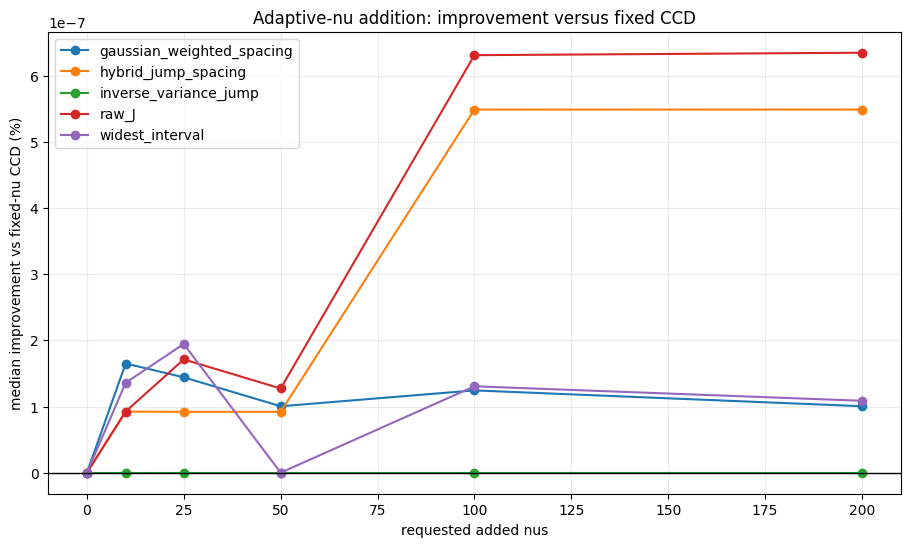

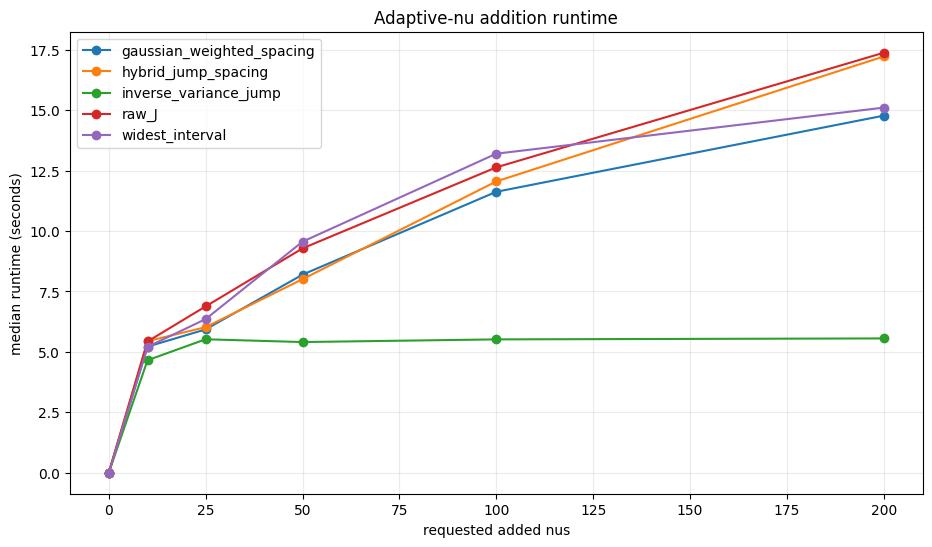

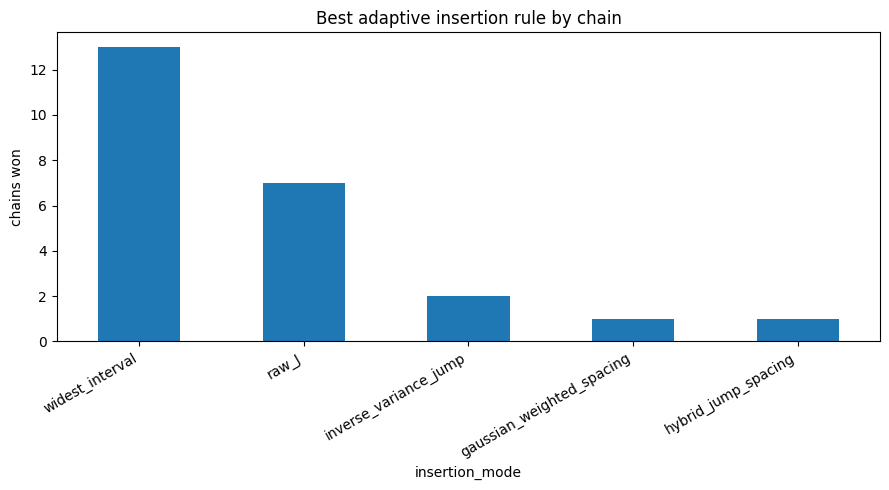

,insertion_mode,requested_added_nus,median_improvement,mean_improvement,median_runtime,median_actual_added,chains
23,raw_J,200,6.346308e-07,0.493813,17.381892,200.0,24
22,raw_J,100,6.309191e-07,0.506328,12.637886,100.0,24
11,hybrid_jump_spacing,200,5.488344e-07,0.476006,17.227292,200.0,24
10,hybrid_jump_spacing,100,5.487467e-07,0.469129,12.055445,100.0,24
26,widest_interval,25,1.945391e-07,0.112561,6.357999,25.0,24
20,raw_J,25,1.712363e-07,0.374398,6.884037,25.0,24
1,gaussian_weighted_spacing,10,1.650319e-07,0.180367,5.218527,10.0,24
2,gaussian_weighted_spacing,25,1.441302e-07,0.224586,5.931425,25.0,24
25,widest_interval,10,1.359666e-07,0.113665,5.209623,10.0,24
28,widest_interval,100,1.306098e-07,0.078594,13.203702,92.0,24


In [61]:
def plot_adaptive_long_results(results):
    if results is None or results.empty:
        print("No adaptive-nu long benchmark results to plot yet.")
        return

    df = results[results["insertion_mode"] != "none"].copy()
    df = df[df["bid_ask_feasible"] == True]
    if df.empty:
        print("No feasible adaptive results to plot yet.")
        return

    summary = (
        df.groupby(["insertion_mode", "requested_added_nus"])
        .agg(
            median_improvement=("improvement_vs_fixed_CCD_pct", "median"),
            mean_improvement=("improvement_vs_fixed_CCD_pct", "mean"),
            median_runtime=("runtime_seconds", "median"),
            median_actual_added=("actual_added_nus", "median"),
            chains=("raw_J", "count"),
        )
        .reset_index()
    )

    plt.figure(figsize=(11, 6))
    for mode, group in summary.groupby("insertion_mode"):
        group = group.sort_values("requested_added_nus")
        plt.plot(group["requested_added_nus"], group["median_improvement"], marker="o", label=mode)
    plt.axhline(0.0, color="black", linewidth=1)
    plt.xlabel("requested added nus")
    plt.ylabel("median improvement vs fixed-nu CCD (%)")
    plt.title("Adaptive-nu addition: improvement versus fixed CCD")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    plt.figure(figsize=(11, 6))
    for mode, group in summary.groupby("insertion_mode"):
        group = group.sort_values("requested_added_nus")
        plt.plot(group["requested_added_nus"], group["median_runtime"], marker="o", label=mode)
    plt.xlabel("requested added nus")
    plt.ylabel("median runtime (seconds)")
    plt.title("Adaptive-nu addition runtime")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    best_by_chain = (
        df.sort_values(["date", "exdate", "raw_J"])
        .groupby(["date", "exdate"], as_index=False)
        .first()
    )
    win_counts = best_by_chain["insertion_mode"].value_counts()
    plt.figure(figsize=(9, 5))
    win_counts.plot(kind="bar")
    plt.ylabel("chains won")
    plt.title("Best adaptive insertion rule by chain")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    display(
        summary.sort_values("median_improvement", ascending=False)
        .head(20)
    )


plot_adaptive_long_results(adaptive_long_results)


## Final conclusion and next direction

The fixed-nu benchmark and the augmented-Lagrangian follow-up point to the same conclusion. For the current LVG parameterization, **20,000-step CCD with the regular adjacent-sigma proxy is already very difficult to improve locally**. Across the 100-chain fixed-nu benchmark, the regular CCD method was the most reliable baseline by median raw `J` and by chain-level win count, while the inverse-variance proxy was close but not consistently better. The full-theta augmented-Lagrangian polish was then run after the feasible `CCD_regular` output on a maturity-bucketed 12-chain subset. It was allowed to move both `nu`s and sigmas, and it could temporarily leave the bid-ask band through the augmented penalty formulation, but final acceptance still required bid-ask feasibility, positive sigmas, ordered `nu`s, and lower raw `J`. The result was essentially no additional improvement beyond CCD, which suggests that the remaining roughness is not mainly a failure of the local optimizer.

The most important next research direction is therefore **adaptive `nu` placement / adaptive `nu` addition**, not more polishing of a fixed-dimensional theta. The existing notebooks use three related ideas. First, they identify large raw-`J` jump locations or large sigma/inverse-variance jumps. Second, they insert a new `nu` inside the corresponding interval, usually at a midpoint or shifted interior location, and initialize the new sigma from neighboring sigmas. Third, they rerun sigma-only coordinate descent so the enlarged theta can settle back inside the bid-ask constraints. This is different from reallocation: adding `nu`s increases `R1` or `R2`, gives the LVG curve more local degrees of freedom, and appears more promising than trying to move the same fixed number of knots. The main open question is no longer whether CCD can smooth a fixed set of knots; it is how to choose **where and how many `nu`s to add** across many SPX chains, while tracking the cost of the extra dimensions.

Recommended next steps:

1. Treat `CCD_regular` as the default fixed-nu baseline.
2. Build a clean adaptive-nu benchmark across many chains: run fixed-nu CCD, locate the largest raw-`J` contributors, add `nu`s by a small set of rules, rerun CCD, and report improvement per added `nu`.
3. Compare addition budgets such as `5`, `10`, `25`, `50`, and `100` so we can see where diminishing returns begin.
4. Keep the inverse-variance proxy as a diagnostic comparison, but do not replace the regular proxy unless it wins consistently on feasible raw `J`.
5. Add downstream diagnostics: implied-volatility curves, `C''`, `C''/V`, and eventually multi-maturity behavior, since the research motivation is not only smaller raw `J` but smoother and more stable LVG/local-vol output.

In short: local optimization after CCD appears saturated. The next contribution should be an algorithmic, data-driven rule for adding `nu`s where the LVG curve needs more flexibility, then testing whether that rule generalizes across many option chains.

Step 13 operationalizes this next direction by running a long checkpointed comparison of several adaptive-nu insertion rules.
